# **Explainable Machine Learning for Predicting Investment Participation: Analysing Investment Behaviour Using SHAP**

**DataSet Link:** https://www.finrafoundation.org/nfcs-data-and-downloads (State-by-State)

**Libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install shap xgboost scikit-learn matplotlib seaborn \
             pandas numpy scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV,
                                     RandomizedSearchCV)
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from xgboost                 import XGBClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (accuracy_score, precision_score,
                                     recall_score, f1_score,
                                     roc_auc_score, confusion_matrix,
                                     classification_report, roc_curve,
                                     average_precision_score)
from sklearn.impute          import SimpleImputer
from scipy.interpolate       import make_interp_spline
from scipy.stats             import gaussian_kde
import matplotlib.cm as cm

DARK   = '#2C2416'
GOLD   = '#C8973A'
MID    = '#8B6914'
CREAM  = '#F5F0E8'
LIGHT  = '#FAF3E4'
WHITE  = '#FFFFFF'

plt.rcParams.update({
    'figure.facecolor' : WHITE,
    'axes.facecolor'   : WHITE,
    'axes.spines.top'  : False,
    'axes.spines.right' : False,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'figure.dpi'       : 130,
})

print("All libraries imported successfully")

All libraries imported successfully


**LOADING THE DATASET**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/NFCS 2024 State Data 250623.csv')
df.head()

,NFCSID,STATEQ,CENSUSDIV,CENSUSREG,A50A,A3Ar_w,A50B,A4A_new_w,A5_2015,A6,...,M6,M7,M8,M31,M50,M9,M10,wgt_n2,wgt_d2,wgt_s3
0,2024010001,36,3,2,2,3,9,1,6,1,...,1,3,98,98,98,1,2,1.153548,1.123949,0.859644
1,2024010002,48,9,4,1,6,6,1,5,5,...,1,3,98,3,3,1,2,1.398688,0.863440,0.975078
2,2024010003,38,9,4,1,6,6,1,4,1,...,1,3,1,98,98,2,2,1.398688,0.472645,0.893974
3,2024010004,48,9,4,2,6,12,1,7,1,...,1,3,1,4,98,1,2,1.250293,0.614156,0.778748
4,2024010005,44,7,3,2,6,12,2,7,4,...,1,3,2,3,2,1,1,1.250076,2.228957,0.783507


In [ ]:
df.shape

(25539, 133)

In [ ]:
df.columns.tolist()

['NFCSID',
 'STATEQ',
 'CENSUSDIV',
 'CENSUSREG',
 'A50A',
 'A3Ar_w',
 'A50B',
 'A4A_new_w',
 'A5_2015',
 'A6',
 'A7',
 'A7A',
 'A11',
 'A8_2021',
 'AM21',
 'X3',
 'A9',
 'A40',
 'A10',
 'A10A',
 'A21_2015',
 'A14',
 'A41',
 'A61',
 'J1',
 'J2',
 'J3',
 'J4',
 'J40',
 'J5',
 'J6',
 'J8',
 'J9',
 'J10',
 'J20',
 'J60_1',
 'J60_2',
 'J60_3',
 'J60_4',
 'J60_5',
 'J60_6',
 'J60_7',
 'J60_90',
 'J60_98',
 'J60_99',
 'J61',
 'J62',
 'J32',
 'J33_40',
 'J63',
 'J64',
 'J41_1',
 'J41_2',
 'J41_3',
 'J42_1',
 'J42_2',
 'J43',
 'J65',
 'J66',
 'B1',
 'B2',
 'B4',
 'B41_1',
 'B41_2',
 'B60',
 'B31',
 'B42',
 'B43',
 'B61',
 'C1_2012',
 'C2_2012',
 'C3_2012',
 'C4_2012',
 'C5_2012',
 'C10_2012',
 'C11_2012',
 'B14A_1',
 'B14A_60',
 'EA_1',
 'E7',
 'E8',
 'E20',
 'E15_2015',
 'E60',
 'P60',
 'P51',
 'P61',
 'F1',
 'F2_1',
 'F2_2',
 'F2_3',
 'F2_4',
 'F2_5',
 'F2_6',
 'G1',
 'G20',
 'G30_1',
 'G30_2',
 'G30_3',
 'G30_4',
 'G30_5',
 'G30_97',
 'G30_98',
 'G30_99',
 'G35',
 'G22_2015',
 'G25_1',
 'G2

**Summary Statistics**

In [ ]:
dataset_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Non-Missing": df.notna().sum(),
    "Missing": df.isna().sum(),
    "Unique Values": df.nunique()
})

dataset_summary

,Data Type,Non-Missing,Missing,Unique Values
NFCSID,int64,25539,0,25539
STATEQ,int64,25539,0,51
CENSUSDIV,int64,25539,0,9
CENSUSREG,int64,25539,0,4
A50A,int64,25539,0,2
...,...,...,...,...
M9,int64,25539,0,4
M10,int64,25539,0,4
wgt_n2,float64,25539,0,526
wgt_d2,float64,25539,0,2362


**Exploratory Data Analysis (EDA)**

**Target Variable Engineering**

**Target Distribution**

In [ ]:
df_raw = df.copy()

df_raw['B14A_1'] = pd.to_numeric(df_raw['B14A_1'], errors='coerce')

print("Raw B14A_1 distribution:")
print(df_raw['B14A_1'].value_counts(dropna=False).sort_index())

df = df_raw[df_raw['B14A_1'].isin([1, 2])].copy()
df['TARGET'] = (df['B14A_1'] == 1).astype(int)
df = df.reset_index(drop=True)

investors     = df['TARGET'].sum()
non_investors = (df['TARGET'] == 0).sum()
total         = len(df)

print(f"\nAfter cleaning:")
print(f"  Total              : {total:,}")
print(f"  Investors    (1)   : {investors:,} ({investors/total*100:.1f}%)")
print(f"  Non-investors (0)  : {non_investors:,} ({non_investors/total*100:.1f}%)")
print(f"  Imbalance ratio    : {non_investors/investors:.2f}:1")

Raw B14A_1 distribution:
B14A_1
1.0      8933
2.0     14523
98.0      806
99.0      252
NaN      1025
Name: count, dtype: int64

After cleaning:
  Total              : 23,456
  Investors    (1)   : 8,933 (38.1%)
  Non-investors (0)  : 14,523 (61.9%)
  Imbalance ratio    : 1.63:1


**Target Visualisation**

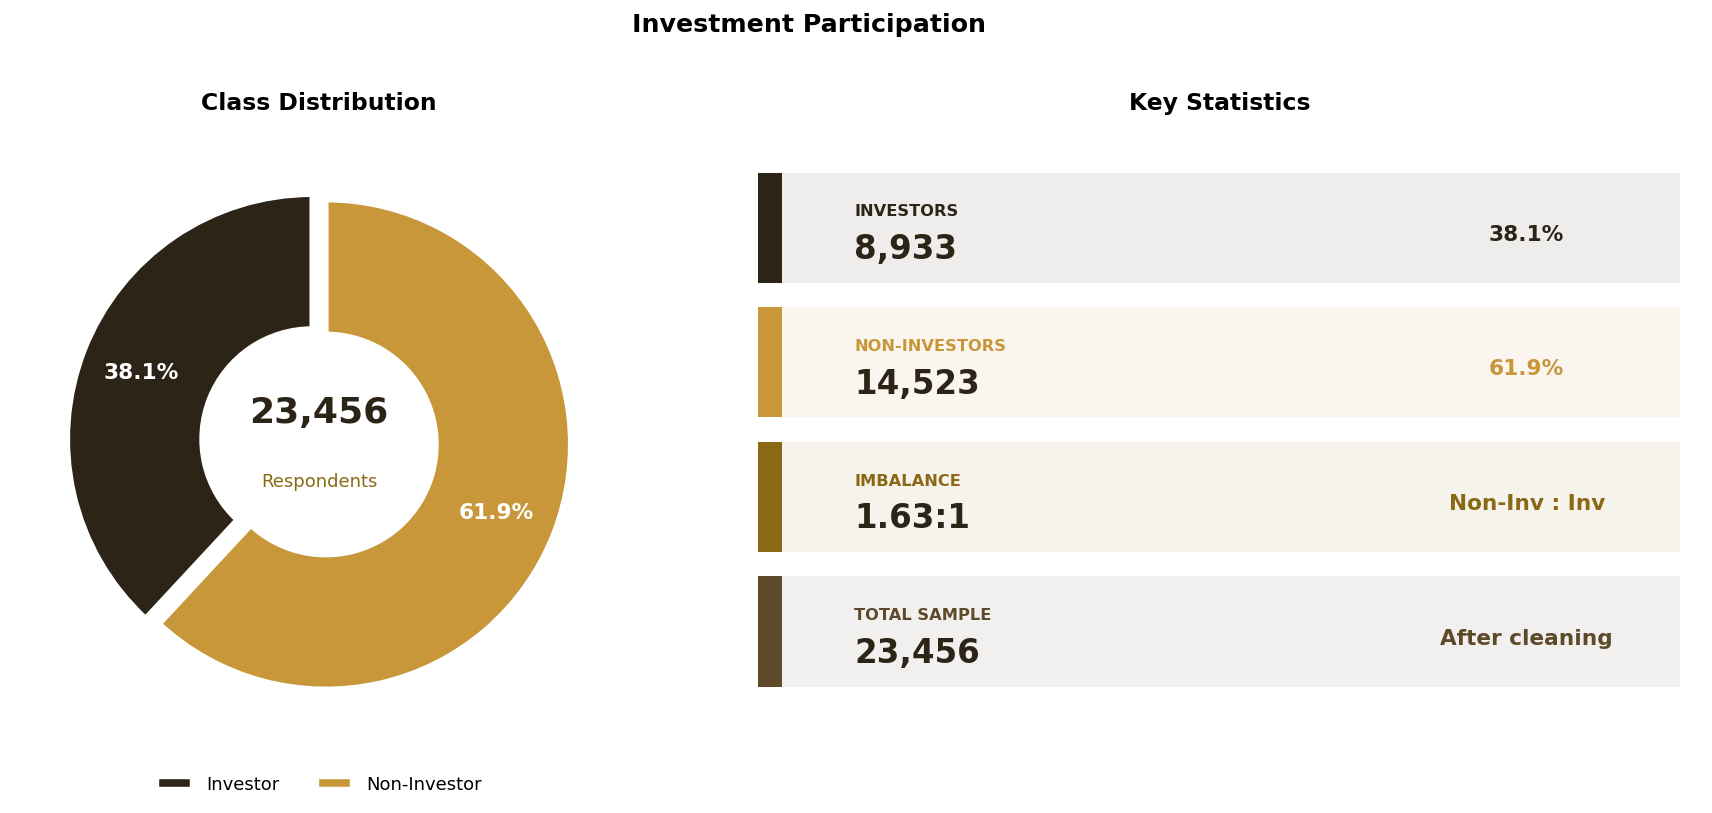

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          gridspec_kw={'width_ratios': [1, 1.2]})
fig.suptitle('Investment Participation',
             fontsize=14, fontweight='bold', y=1.02)

ax1 = axes[0]
wedges, texts, autotexts = ax1.pie(
    [investors, non_investors],
    colors=[DARK, GOLD],
    explode=(0.03, 0.03),
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor=WHITE, linewidth=3),
    textprops={'fontsize': 12})
for at in autotexts:
    at.set_color(WHITE)
    at.set_fontweight('bold')
ax1.text(0, 0.08, f'{total:,}', ha='center',
         fontsize=20, fontweight='bold', color=DARK)
ax1.text(0, -0.18, 'Respondents', ha='center',
         fontsize=10, color=MID)
ax1.legend(['Investor', 'Non-Investor'],
           loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           ncol=2, frameon=False)
ax1.set_title('Class Distribution', fontweight='bold', pad=15)

ax2 = axes[1]
ax2.axis('off')
stats = [
    {'label':'INVESTORS',     'value':f'{investors:,}',
     'pct':f'{investors/total*100:.1f}%',     'color':DARK},
    {'label':'NON-INVESTORS', 'value':f'{non_investors:,}',
     'pct':f'{non_investors/total*100:.1f}%', 'color':GOLD},
    {'label':'IMBALANCE',     'value':f'{non_investors/investors:.2f}:1',
     'pct':'Non-Inv : Inv',                   'color':MID},
    {'label':'TOTAL SAMPLE',  'value':f'{total:,}',
     'pct':'After cleaning',                  'color':'#5C4A2A'},
]
for i, s in enumerate(stats):
    y_pos = 0.85 - i * 0.22
    rect = plt.Rectangle((0.02, y_pos-0.09), 0.96, 0.18,
                          transform=ax2.transAxes,
                          facecolor=s['color'], alpha=0.08)
    bar  = plt.Rectangle((0.02, y_pos-0.09), 0.025, 0.18,
                          transform=ax2.transAxes,
                          facecolor=s['color'])
    ax2.add_patch(rect)
    ax2.add_patch(bar)
    ax2.text(0.12, y_pos+0.02, s['label'],
             transform=ax2.transAxes,
             fontsize=9, color=s['color'], fontweight='bold')
    ax2.text(0.12, y_pos-0.05, s['value'],
             transform=ax2.transAxes,
             fontsize=18, color=DARK, fontweight='bold')
    ax2.text(0.82, y_pos-0.02, s['pct'],
             transform=ax2.transAxes,
             fontsize=12, color=s['color'],
             fontweight='bold', ha='center')
ax2.set_title('Key Statistics', fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

**Feature Selection & Variable Description**

In [ ]:
DEMO_COLS = [
    'A50A',
    'A3Ar_w',
    'A5_2015',
    'A8_2021',
    'A9'
]

FIN_COLS = [
    'J1',
    'J3',
    'J4',
    'J5',
    'G20',
    'B1',
    'B2',
    'B61'
]

RISK_COLS = ['J2']

KNOW_COLS = ['M4']

LIT_COLS = [
    'M6',
    'M7',
    'M8',
    'M9',
    'M10'
]

FEATURE_COLS = (
    DEMO_COLS +
    FIN_COLS +
    RISK_COLS +
    KNOW_COLS +
    LIT_COLS
)

CORRECT_ANS = {
    'M6': 1,
    'M7': 3,
    'M8': 2,
    'M9': 1,
    'M10': 2
}

RENAME = {
    'A50A': 'Gender',
    'A3Ar_w': 'Age Group',
    'A5_2015': 'Education Level',
    'A8_2021': 'Income Level',
    'A9': 'Employment Status',
    'J1': 'Financial Satisfaction',
    'J3': 'Spending vs Income',
    'J4': 'Expense Difficulty',
    'J5': 'Has Emergency Savings',
    'G20': 'Has Medical Debt',
    'B1': 'Has Checking Account',
    'B2': 'Has Savings Account',
    'B61': 'Interest in AI Advice',
    'J2': 'Risk Willingness',
    'M4': 'Financial Knowledge (Self-rated)',
    'financial_literacy_score': 'Financial Literacy Score',
}

print("Feature Groups:")
print(f"  Demographic          : {DEMO_COLS}")
print(f"  Financial behaviour  : {FIN_COLS}")
print(f"  Risk attitude        : {RISK_COLS}")
print(f"  Financial knowledge  : {KNOW_COLS}")
print(f"  Literacy quiz        : {LIT_COLS} → engineered to score")
print(f"\n  Total features selected : {len(FEATURE_COLS)}")
print(
    f"  Final features (after engineering) : "
    f"{len(FEATURE_COLS)-len(LIT_COLS)+1}"
)

Feature Groups:
  Demographic          : ['A50A', 'A3Ar_w', 'A5_2015', 'A8_2021', 'A9']
  Financial behaviour  : ['J1', 'J3', 'J4', 'J5', 'G20', 'B1', 'B2', 'B61']
  Risk attitude        : ['J2']
  Financial knowledge  : ['M4']
  Literacy quiz        : ['M6', 'M7', 'M8', 'M9', 'M10'] → engineered to score

  Total features selected : 20
  Final features (after engineering) : 16


**EDA Preparation**

In [ ]:
# Replace coded missing for EDA only
df_eda = df[['NFCSID'] + FEATURE_COLS + ['TARGET']].copy()

for col in FEATURE_COLS:
    df_eda[col] = pd.to_numeric(df_eda[col], errors='coerce')
    df_eda[col] = df_eda[col].replace({98: np.nan, 99: np.nan})

# Pre-calculate literacy score for EDA
for col, ans in CORRECT_ANS.items():
    df_eda[f'{col}_c'] = np.where(
        df_eda[col].isna(), np.nan,
        (df_eda[col] == ans).astype(float))

lit_c_cols = [f'{c}_c' for c in LIT_COLS]
df_eda['lit_score_preview'] = df_eda[lit_c_cols].sum(axis=1)

print(f"EDA dataframe ready : {df_eda.shape}")

EDA dataframe ready : (23456, 28)


**Demographic Investment Rates**

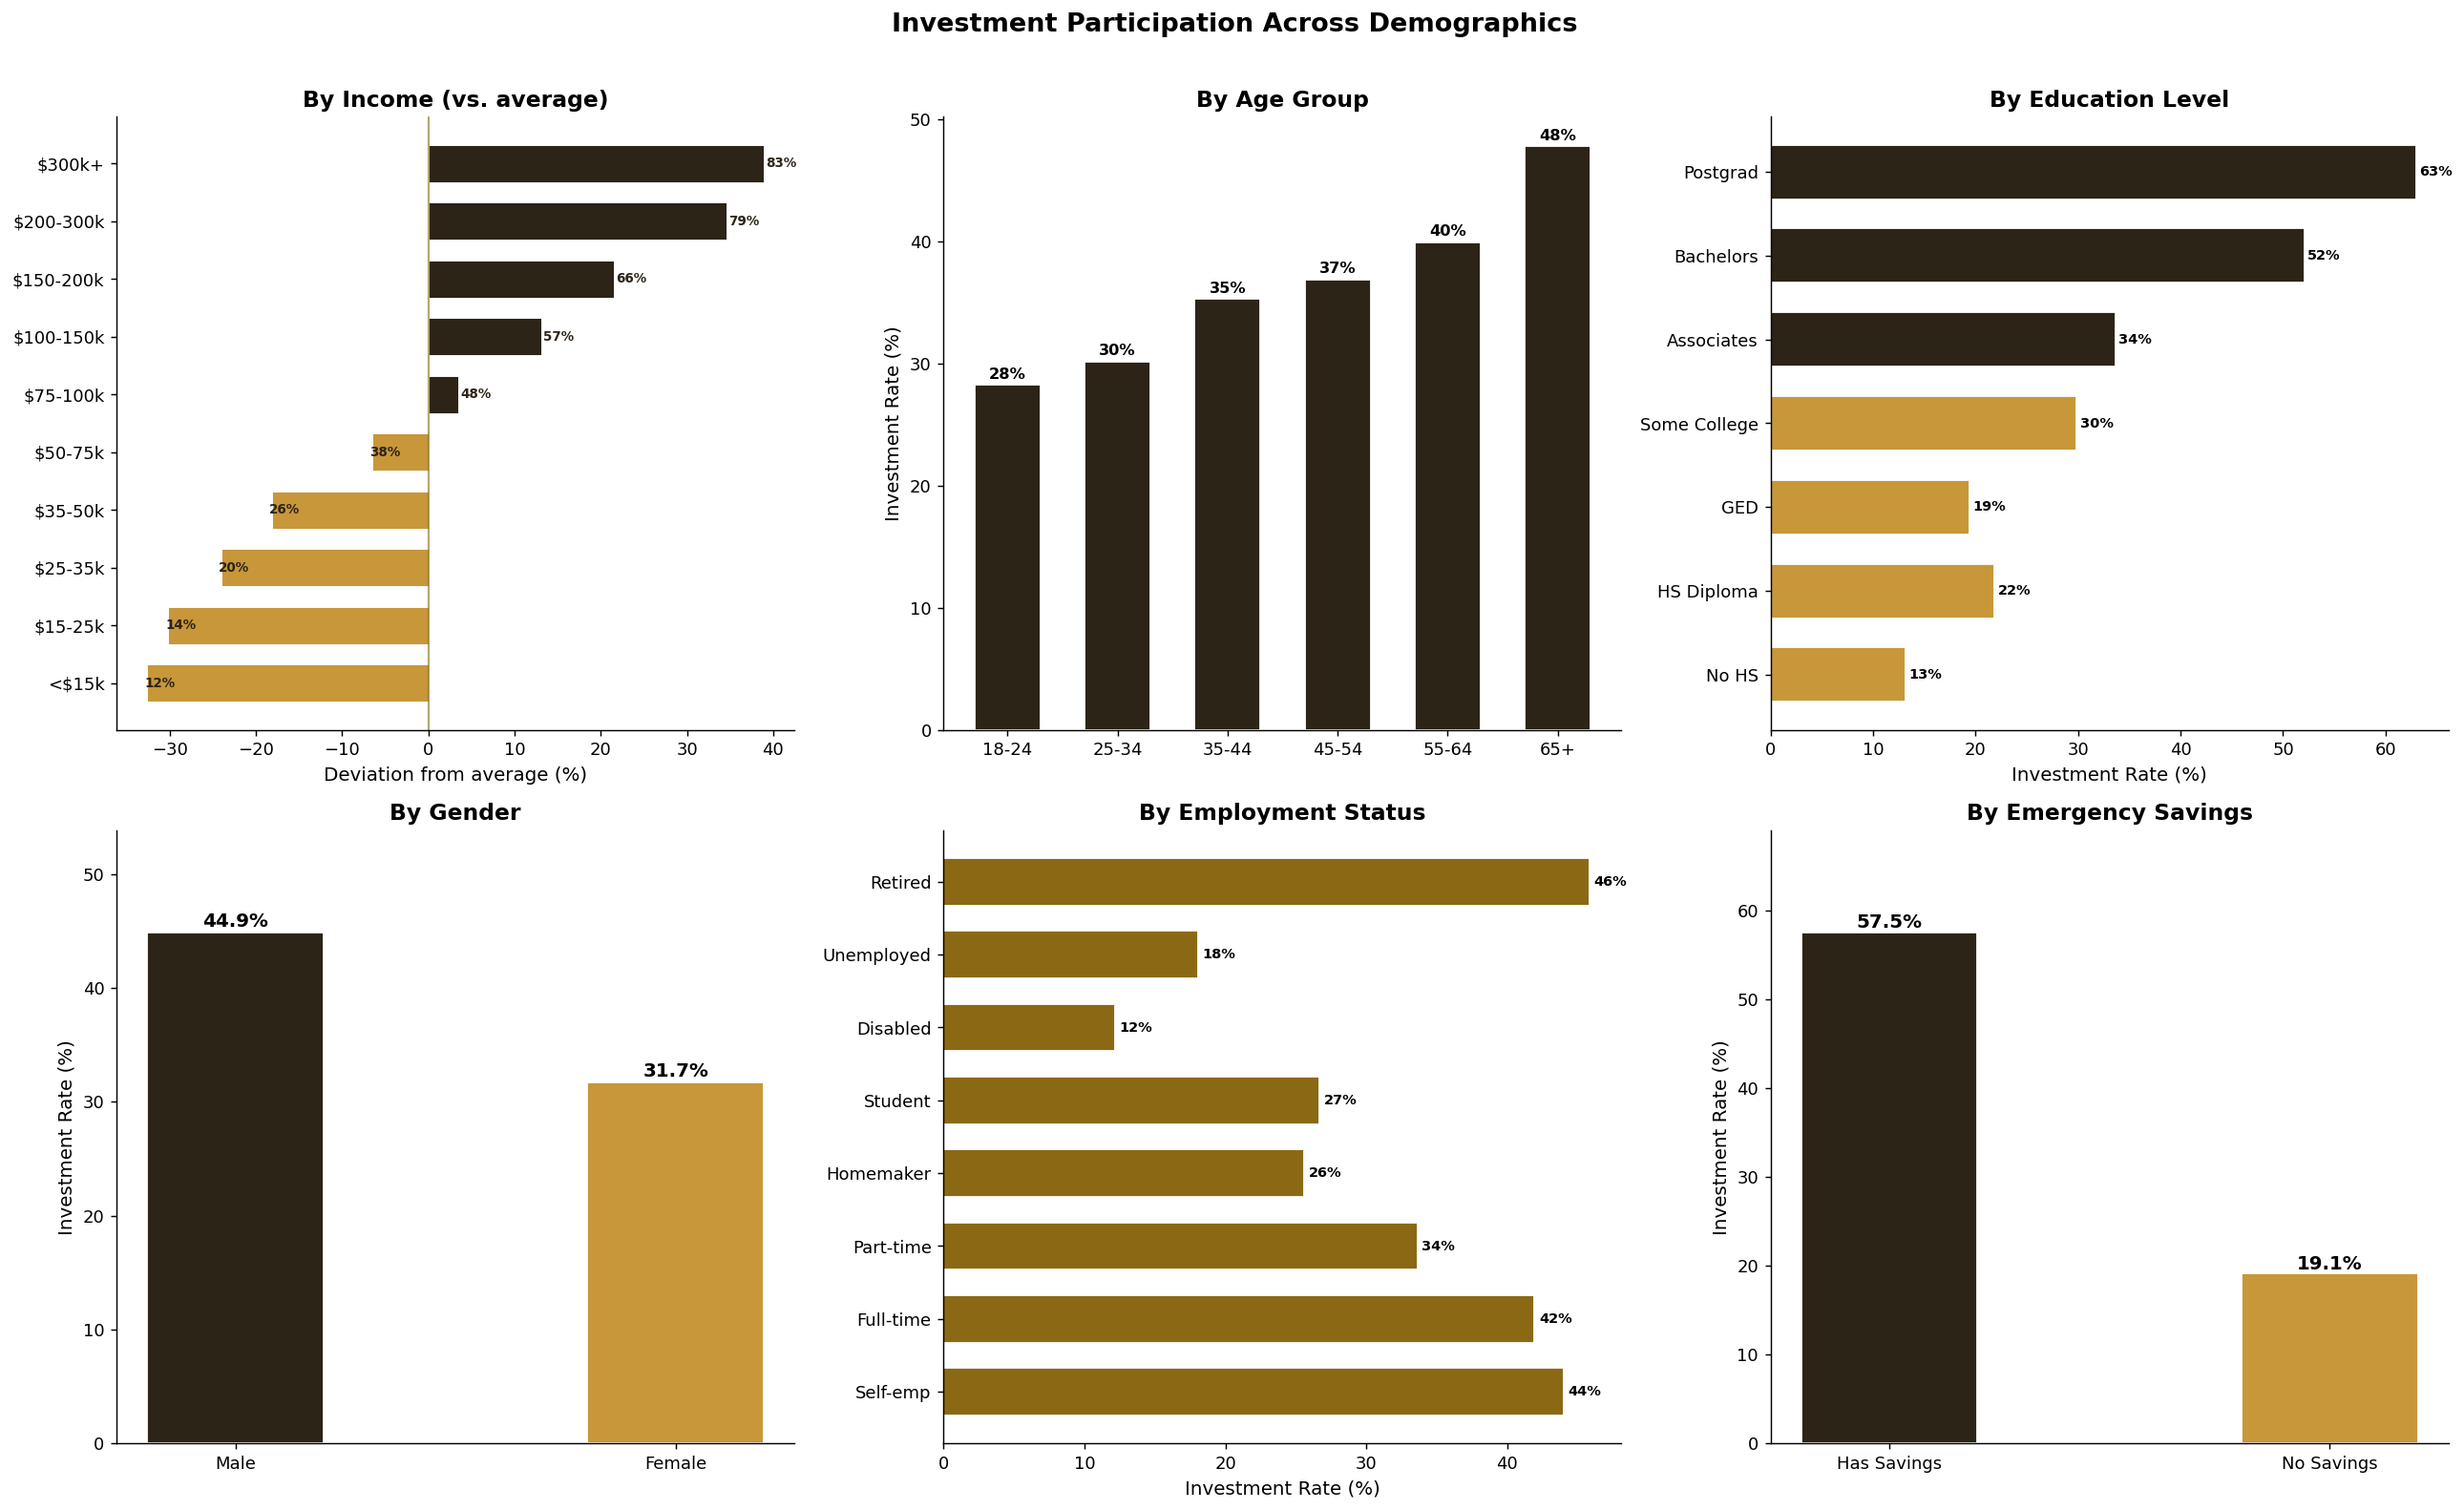

In [ ]:
fig = plt.figure(figsize=(20, 12))
fig.suptitle('Investment Participation Across Demographics',
             fontsize=15, fontweight='bold', y=1.01)

# Income
ax1 = fig.add_subplot(2, 3, 1)
inc_lab = {1:'<$15k', 2:'$15-25k', 3:'$25-35k',
           4:'$35-50k', 5:'$50-75k', 6:'$75-100k',
           7:'$100-150k', 8:'$150-200k',
           9:'$200-300k', 10:'$300k+'}
inv_inc = df_eda.groupby('A8_2021')['TARGET'].mean() * 100
inv_inc.index = [inc_lab.get(int(i), str(i)) for i in inv_inc.index]
overall = inv_inc.mean()
div     = inv_inc - overall
col_div = [DARK if v >= 0 else GOLD for v in div.values]
ax1.barh(div.index, div.values, color=col_div,
         edgecolor=WHITE, linewidth=0.5, height=0.65)
ax1.axvline(0, color=MID, linewidth=1.2, alpha=0.6)
ax1.set_title('By Income (vs. average)', fontweight='bold')
ax1.set_xlabel('Deviation from average (%)')
for i, (v, raw) in enumerate(zip(div.values, inv_inc.values)):
    xp = v+0.3 if v >= 0 else v-0.3
    ha = 'left' if v >= 0 else 'right'
    ax1.text(xp, i, f'{raw:.0f}%', va='center',
             fontsize=7.5, fontweight='bold', color=DARK)

# Age
ax2 = fig.add_subplot(2, 3, 2)
age_lab = {1:'18-24', 2:'25-34', 3:'35-44',
           4:'45-54', 5:'55-64', 6:'65+'}
inv_age = df_eda.groupby('A3Ar_w')['TARGET'].mean() * 100
inv_age.index = [age_lab.get(int(i), str(i)) for i in inv_age.index]
ax2.bar(inv_age.index, inv_age.values,
        color=DARK, edgecolor=WHITE, width=0.6)
ax2.set_title('By Age Group', fontweight='bold')
ax2.set_ylabel('Investment Rate (%)')
for i, v in enumerate(inv_age.values):
    ax2.text(i, v+0.5, f'{v:.0f}%', ha='center',
             fontsize=9, fontweight='bold')

# Education
ax3 = fig.add_subplot(2, 3, 3)
edu_lab = {1:'No HS', 2:'HS Diploma', 3:'GED',
           4:'Some College', 5:'Associates',
           6:'Bachelors', 7:'Postgrad'}
inv_edu = df_eda.groupby('A5_2015')['TARGET'].mean() * 100
inv_edu.index = [edu_lab.get(int(i), str(i)) for i in inv_edu.index]
col_edu = [DARK if v > inv_edu.mean() else GOLD for v in inv_edu.values]
ax3.barh(inv_edu.index, inv_edu.values,
         color=col_edu, edgecolor=WHITE, height=0.65)
ax3.set_title('By Education Level', fontweight='bold')
ax3.set_xlabel('Investment Rate (%)')
for i, v in enumerate(inv_edu.values):
    ax3.text(v+0.3, i, f'{v:.0f}%', va='center',
             fontsize=8, fontweight='bold')

# Gender
ax4 = fig.add_subplot(2, 3, 4)
gen_lab = {1:'Male', 2:'Female'}
inv_gen = df_eda.groupby('A50A')['TARGET'].mean() * 100
inv_gen.index = [gen_lab.get(int(i), str(i)) for i in inv_gen.index]
bars4 = ax4.bar(inv_gen.index, inv_gen.values,
                color=[DARK, GOLD], edgecolor=WHITE, width=0.4)
ax4.set_title('By Gender', fontweight='bold')
ax4.set_ylabel('Investment Rate (%)')
ax4.set_ylim(0, inv_gen.max() * 1.2)
for bar, v in zip(bars4, inv_gen.values):
    ax4.text(bar.get_x()+bar.get_width()/2,
             v+0.5, f'{v:.1f}%', ha='center',
             fontsize=11, fontweight='bold')

# Employment
ax5 = fig.add_subplot(2, 3, 5)
emp_lab = {1:'Self-emp', 2:'Full-time', 3:'Part-time',
           4:'Homemaker', 5:'Student',
           6:'Disabled', 7:'Unemployed', 8:'Retired'}
inv_emp = df_eda.groupby('A9')['TARGET'].mean() * 100
inv_emp.index = [emp_lab.get(int(i), str(i)) for i in inv_emp.index]
ax5.barh(inv_emp.index, inv_emp.values,
         color=MID, edgecolor=WHITE, height=0.65)
ax5.set_title('By Employment Status', fontweight='bold')
ax5.set_xlabel('Investment Rate (%)')
for i, v in enumerate(inv_emp.values):
    ax5.text(v+0.3, i, f'{v:.0f}%', va='center',
             fontsize=8, fontweight='bold')

# Emergency savings
ax6 = fig.add_subplot(2, 3, 6)
sav_lab = {1:'Has Savings', 2:'No Savings'}
inv_sav = df_eda.groupby('J5')['TARGET'].mean() * 100
inv_sav.index = [sav_lab.get(int(i), str(i)) for i in inv_sav.index]
bars6 = ax6.bar(inv_sav.index, inv_sav.values,
                color=[DARK, GOLD], edgecolor=WHITE, width=0.4)
ax6.set_title('By Emergency Savings', fontweight='bold')
ax6.set_ylabel('Investment Rate (%)')
ax6.set_ylim(0, inv_sav.max() * 1.2)
for bar, v in zip(bars6, inv_sav.values):
    ax6.text(bar.get_x()+bar.get_width()/2,
             v+0.5, f'{v:.1f}%', ha='center',
             fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

**Risk Willingness Analysis**

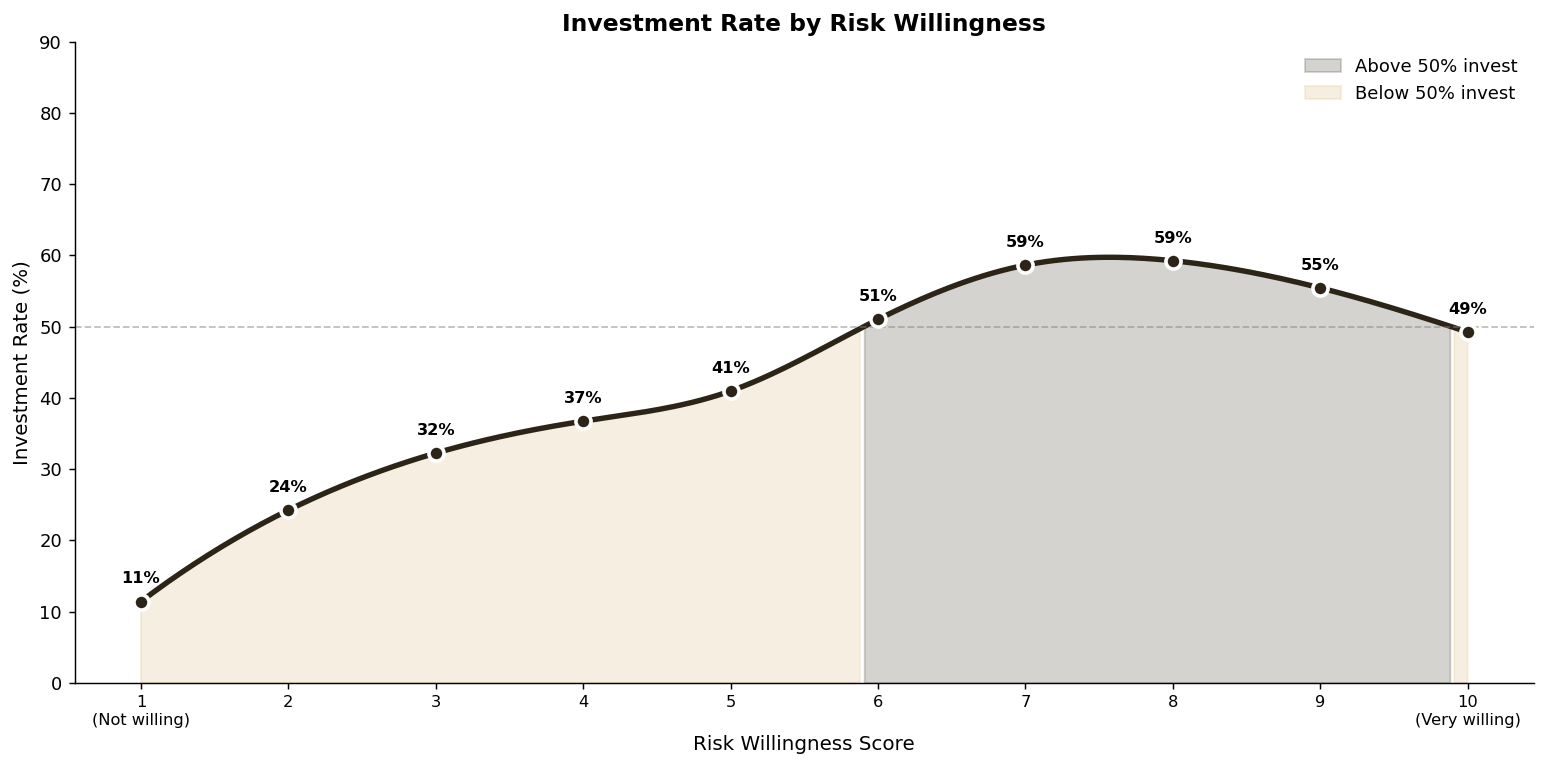

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

risk_rate = df_eda.groupby('J2')['TARGET'].mean() * 100
rx = risk_rate.index.astype(float)
ry = risk_rate.values

x_sm   = np.linspace(rx.min(), rx.max(), 300)
spline = make_interp_spline(rx, ry, k=3)
y_sm   = spline(x_sm)

ax.plot(x_sm, y_sm, color=DARK, linewidth=3)
ax.fill_between(x_sm, y_sm,
                where=(y_sm >= 50),
                alpha=0.2, color=DARK,
                label='Above 50% invest')
ax.fill_between(x_sm, y_sm,
                where=(y_sm < 50),
                alpha=0.15, color=GOLD,
                label='Below 50% invest')
ax.scatter(rx, ry, color=DARK, s=70, zorder=5,
           edgecolors=WHITE, linewidth=2)
for x, y in zip(rx, ry):
    ax.annotate(f'{y:.0f}%', (x, y),
                xytext=(0, 10),
                textcoords='offset points',
                ha='center', fontsize=9,
                fontweight='bold')
ax.axhline(50, color='grey', linewidth=1,
           linestyle='--', alpha=0.5)
ax.set_xticks(range(1, 11))
ax.set_xticklabels(
    ['1\n(Not willing)','2','3','4','5',
     '6','7','8','9','10\n(Very willing)'],
    fontsize=9)
ax.set_xlabel('Risk Willingness Score')
ax.set_ylabel('Investment Rate (%)')
ax.set_title('Investment Rate by Risk Willingness',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 90)
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

**Financial Literacy Analysis**

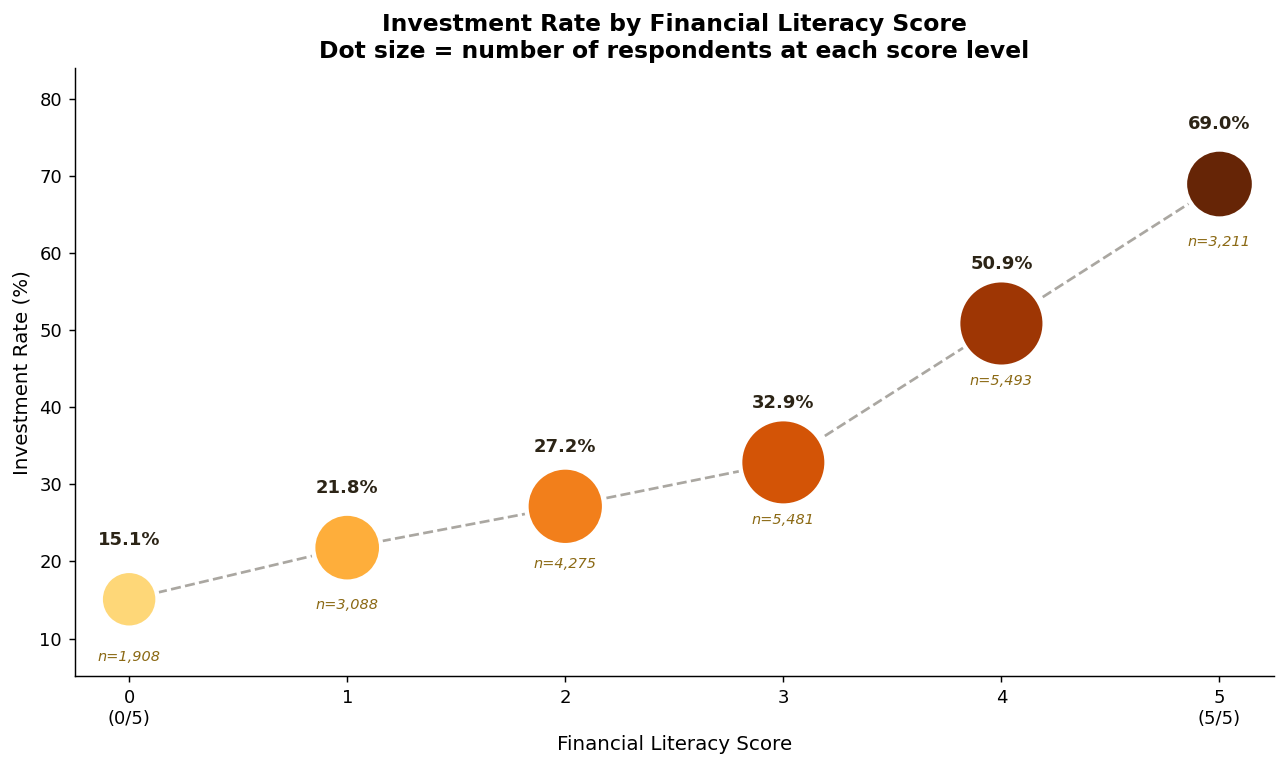

In [ ]:
lit_rate = df_eda.groupby(
    'lit_score_preview'
)['TARGET'].mean() * 100

lit_count = df_eda.groupby(
    'lit_score_preview'
)['TARGET'].count()

fig, ax = plt.subplots(figsize=(10, 6))

cmap_c = cm.get_cmap('YlOrBr')

colors_dot = [
    cmap_c(0.3 + 0.14 * s)
    for s in lit_rate.index
]

sizes = (
    lit_count.values / lit_count.max()
) * 2000 + 300

ax.plot(
    lit_rate.index,
    lit_rate.values,
    color=DARK,
    linewidth=1.5,
    alpha=0.4,
    linestyle='--'
)

ax.scatter(
    lit_rate.index,
    lit_rate.values,
    s=sizes,
    c=colors_dot,
    zorder=5,
    edgecolors=WHITE,
    linewidth=2.5
)

for s, r, c in zip(
    lit_rate.index,
    lit_rate.values,
    lit_count.values
):

    ax.annotate(
        f'{r:.1f}%',
        xy=(s, r),
        xytext=(0, 28),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color=DARK
    )

    ax.annotate(
        f'n={c:,}',
        xy=(s, r),
        xytext=(0, -28),
        textcoords='offset points',
        ha='center',
        va='top',
        fontsize=8,
        color=MID,
        style='italic'
    )

ax.set_xticks(range(6))

ax.set_xticklabels([
    '0\n(0/5)',
    '1',
    '2',
    '3',
    '4',
    '5\n(5/5)'
])

ax.set_xlabel('Financial Literacy Score')
ax.set_ylabel('Investment Rate (%)')

ax.set_title(
    'Investment Rate by Financial Literacy Score\n'
    'Dot size = number of respondents at each score level',
    fontsize=13,
    fontweight='bold'
)

ax.set_ylim(
    max(0, lit_rate.min() - 10),
    min(100, lit_rate.max() + 15)
)

plt.tight_layout()
plt.show()

**AI Advice Interest & Financial Satisfaction**

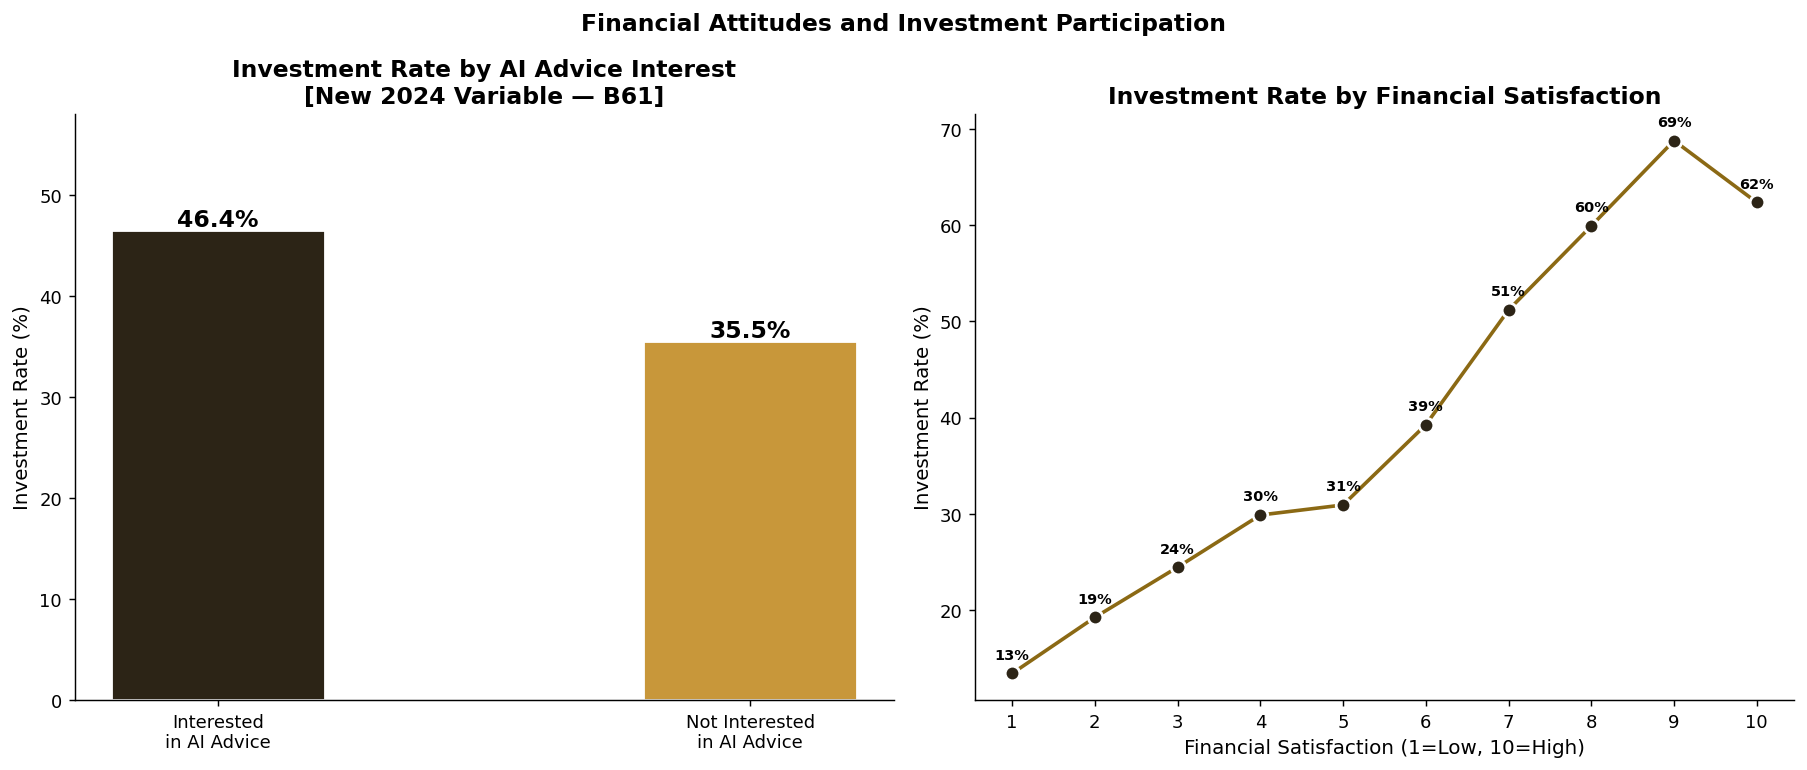

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle(
    'Financial Attitudes and Investment Participation',
    fontsize=13,
    fontweight='bold'
)

# AI advice interest
ax1 = axes[0]

ai_lab = {
    1: 'Interested\nin AI Advice',
    2: 'Not Interested\nin AI Advice'
}

ai_rate = df_eda.groupby('B61')['TARGET'].mean() * 100

ai_rate.index = [
    ai_lab.get(int(i), str(i))
    for i in ai_rate.index
]

bars1 = ax1.bar(
    ai_rate.index,
    ai_rate.values,
    color=[DARK, GOLD],
    edgecolor=WHITE,
    width=0.4
)

ax1.set_title(
    'Investment Rate by AI Advice Interest\n'
    '[New 2024 Variable — B61]',
    fontweight='bold'
)

ax1.set_ylabel('Investment Rate (%)')
ax1.set_ylim(0, ai_rate.max() * 1.25)

for bar, v in zip(bars1, ai_rate.values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.5,
        f'{v:.1f}%',
        ha='center',
        fontsize=13,
        fontweight='bold'
    )

# Financial satisfaction
ax2 = axes[1]

sat_rate = (
    df_eda.groupby('J1')['TARGET'].mean() * 100
)

sx = sat_rate.index.astype(float)
sy = sat_rate.values

ax2.plot(
    sx,
    sy,
    color=MID,
    linewidth=2
)

ax2.scatter(
    sx,
    sy,
    color=DARK,
    s=65,
    zorder=5,
    edgecolors=WHITE,
    linewidth=1.5
)

for x, y in zip(sx, sy):
    ax2.annotate(
        f'{y:.0f}%',
        (x, y),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        fontweight='bold'
    )

ax2.set_xlabel(
    'Financial Satisfaction (1=Low, 10=High)'
)

ax2.set_ylabel('Investment Rate (%)')

ax2.set_title(
    'Investment Rate by Financial Satisfaction',
    fontweight='bold'
)

ax2.set_xticks(sx)

plt.tight_layout()
plt.show()

**Correlation Heatmap**

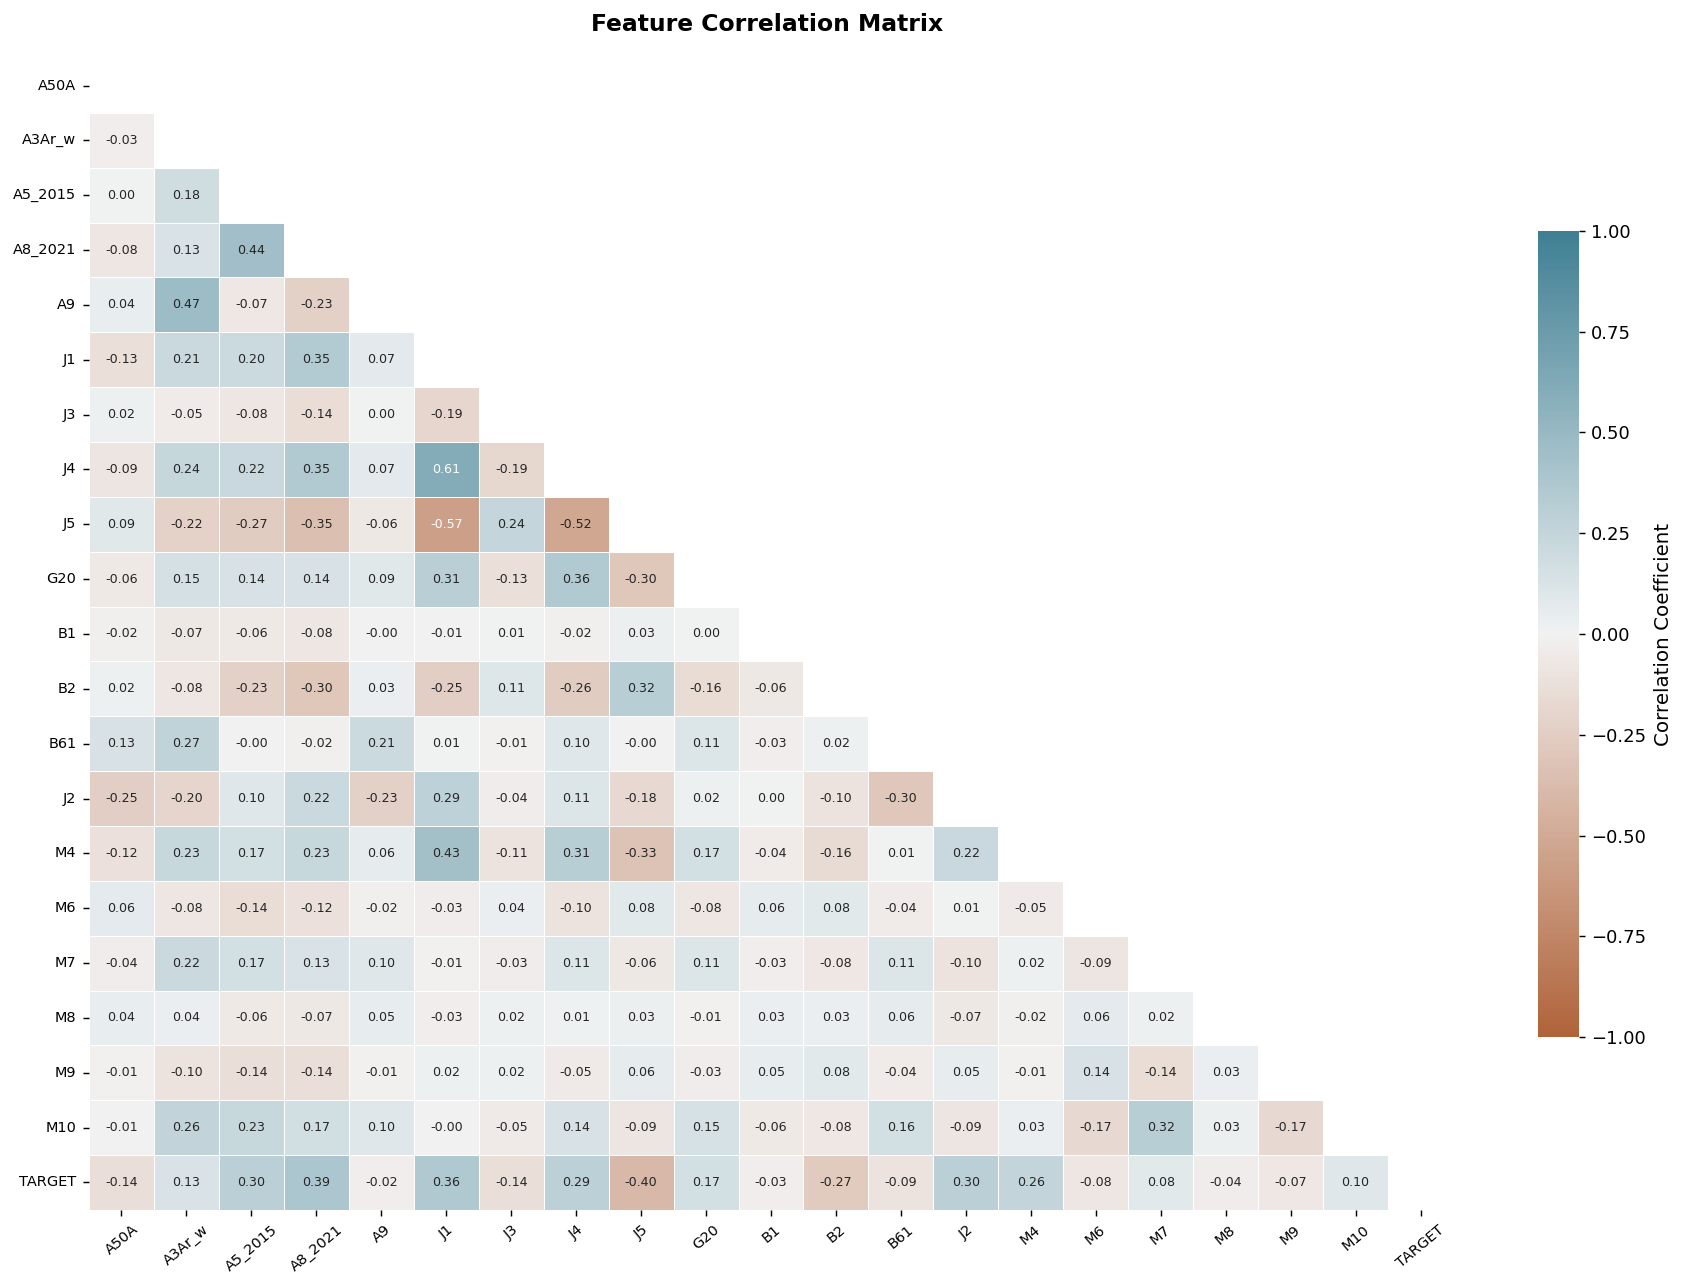

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

eda_numeric = df_eda[FEATURE_COLS + ['TARGET']].copy()
corr        = eda_numeric.corr()
mask        = np.triu(np.ones_like(corr, dtype=bool))
cmap        = sns.diverging_palette(30, 220, as_cmap=True)

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap=cmap, center=0,
            linewidths=0.3, linecolor=WHITE,
            ax=ax, annot_kws={'size': 7},
            vmin=-1, vmax=1,
            cbar_kws={'shrink':0.7,
                      'label':'Correlation Coefficient'})
ax.set_title('Feature Correlation Matrix ',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=40, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.show()

**PREPROCESSING**

**Replace Coded Missing Values**

In [ ]:
df_model = df[['NFCSID'] + FEATURE_COLS + ['TARGET']].copy()

for col in FEATURE_COLS:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')
    df_model[col] = df_model[col].replace({98: np.nan, 99: np.nan})

print("Coded missing values replaced with NaN")
print("  98 = Don't Know → NaN")
print("  99 = Refuse to Answer → NaN")

Coded missing values replaced with NaN
  98 = Don't Know → NaN
  99 = Refuse to Answer → NaN


**Missing Value Analysis**

In [ ]:
miss = pd.DataFrame({
    'Missing Count': df_model[FEATURE_COLS].isnull().sum(),
    'Missing %'    : (df_model[FEATURE_COLS].isnull().sum() /
                      len(df_model) * 100).round(2)
}).sort_values('Missing %', ascending=False)

print("Missing Value Summary:")
print(miss[miss['Missing Count'] > 0].to_string())
print(f"\nTotal features with missing values : "
      f"{(miss['Missing Count'] > 0).sum()}")
print(f"Total missing values               : "
      f"{df_model[FEATURE_COLS].isnull().sum().sum():,}")
print(f"\nNote: Missing values will be handled by median")
print(f"imputation fitted on training data only (Step 7.2)")

Missing Value Summary:
     Missing Count  Missing %
M10          10695      45.60
M8            9696      41.34
B61           4874      20.78
M7            4756      20.28
M9            4376      18.66
M6            3383      14.42
J5             553       2.36
G20            506       2.16
J3             490       2.09
J2             364       1.55
B2             341       1.45
M4             325       1.39
J4             305       1.30
B1             299       1.27
J1             183       0.78

Total features with missing values : 15
Total missing values               : 41,146

Note: Missing values will be handled by median
imputation fitted on training data only (Step 7.2)


**Financial Literacy Score Engineering**

In [ ]:
print("\nCorrect answers per NFCS 2024 questionnaire:")
print("  M6  → 1  (compound interest)")
print("  M7  → 3  (inflation reduces purchasing power)")
print("  M8  → 2  (bond prices fall when rates rise)")
print("  M9  → 1  (15yr mortgage = less total interest)")
print("  M10 → 2  (mutual funds safer than single stock)")

for col, ans in CORRECT_ANS.items():
    df_model[f'{col}_correct'] = np.where(
        df_model[col].isna(), np.nan,
        (df_model[col] == ans).astype(float))

lit_correct_cols = [f'{c}_correct' for c in LIT_COLS]
df_model['financial_literacy_score'] = \
    df_model[lit_correct_cols].sum(axis=1)

print(f" Financial literacy score engineered (range 0-5)")
print(f"  Mean score   : {df_model['financial_literacy_score'].mean():.2f}/5")
print(f"  Distribution :")
print(df_model['financial_literacy_score'].value_counts().sort_index())


Correct answers per NFCS 2024 questionnaire:
  M6  → 1  (compound interest)
  M7  → 3  (inflation reduces purchasing power)
  M8  → 2  (bond prices fall when rates rise)
  M9  → 1  (15yr mortgage = less total interest)
  M10 → 2  (mutual funds safer than single stock)
 Financial literacy score engineered (range 0-5)
  Mean score   : 2.82/5
  Distribution :
financial_literacy_score
0.0    1908
1.0    3088
2.0    4275
3.0    5481
4.0    5493
5.0    3211
Name: count, dtype: int64


**Build Feature Matrix**

In [ ]:
NON_LIT_COLS   = [c for c in FEATURE_COLS if c not in LIT_COLS]
FINAL_FEATURES = NON_LIT_COLS + ['financial_literacy_score']
FINAL_FEATURES = [c for c in FINAL_FEATURES
                  if c in df_model.columns]

X = df_model[FINAL_FEATURES].copy().reset_index(drop=True)
y = df_model['TARGET'].copy().reset_index(drop=True)

print(f" Feature matrix built")
print(f"  Rows     : {X.shape[0]:,}")
print(f"  Features : {X.shape[1]}")
print(f"  Target   : {y.sum():,} investors / "
      f"{(y==0).sum():,} non-investors")

 Feature matrix built
  Rows     : 23,456
  Features : 16
  Target   : 8,933 investors / 14,523 non-investors


**TRAIN/TEST SPLIT**

In [ ]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

print(f" Train/Test split complete (80/20 stratified)")
print(f"  Training set   : {X_train_raw.shape[0]:,} samples")
print(f"  Test set       : {X_test_raw.shape[0]:,} samples")
print(f"  Train investors: {y_train.mean()*100:.1f}%")
print(f"  Test investors : {y_test.mean()*100:.1f}%")

 Train/Test split complete (80/20 stratified)
  Training set   : 18,764 samples
  Test set       : 4,692 samples
  Train investors: 38.1%
  Test investors : 38.1%


**Imputation After Split**

In [ ]:
imputer = SimpleImputer(strategy='median')

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_raw),
    columns=FINAL_FEATURES)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test_raw),
    columns=FINAL_FEATURES)

print(f"  Train missing after : {X_train_imp.isnull().sum().sum()}")
print(f"  Test missing after  : {X_test_imp.isnull().sum().sum()}")

  Train missing after : 0
  Test missing after  : 0


**Rename Features**

In [ ]:
X_train_imp   = X_train_imp.rename(columns=RENAME)
X_test_imp    = X_test_imp.rename(columns=RENAME)
FEATURE_NAMES = list(X_train_imp.columns)

print(f" Features renamed ({len(FEATURE_NAMES)} total):")
for i, f in enumerate(FEATURE_NAMES, 1):
    print(f"  {i:2d}. {f}")

 Features renamed (16 total):
   1. Gender
   2. Age Group
   3. Education Level
   4. Income Level
   5. Employment Status
   6. Financial Satisfaction
   7. Spending vs Income
   8. Expense Difficulty
   9. Has Emergency Savings
  10. Has Medical Debt
  11. Has Checking Account
  12. Has Savings Account
  13. Interest in AI Advice
  14. Risk Willingness
  15. Financial Knowledge (Self-rated)
  16. Financial Literacy Score


**Class Imbalance Handling**

In [ ]:
inv_count     = y_train.sum()
non_inv_count = (y_train == 0).sum()
scale_pos_w   = non_inv_count / inv_count

print(f"Training set class distribution:")
print(f"  Investors     : {inv_count:,} ({y_train.mean()*100:.1f}%)")
print(f"  Non-investors : {non_inv_count:,} ({(y_train==0).mean()*100:.1f}%)")
print(f"  Imbalance     : {scale_pos_w:.2f}:1")
print(f"\nApproach: class_weight='balanced' for LR and RF")
print(f"          scale_pos_weight={scale_pos_w:.2f} for XGBoost")
print(f"  Models will internally compensate for imbalance")

Training set class distribution:
  Investors     : 7,146 (38.1%)
  Non-investors : 11,618 (61.9%)
  Imbalance     : 1.63:1

Approach: class_weight='balanced' for LR and RF
          scale_pos_weight=1.63 for XGBoost
  Models will internally compensate for imbalance


**Class Imbalance Visualisation**

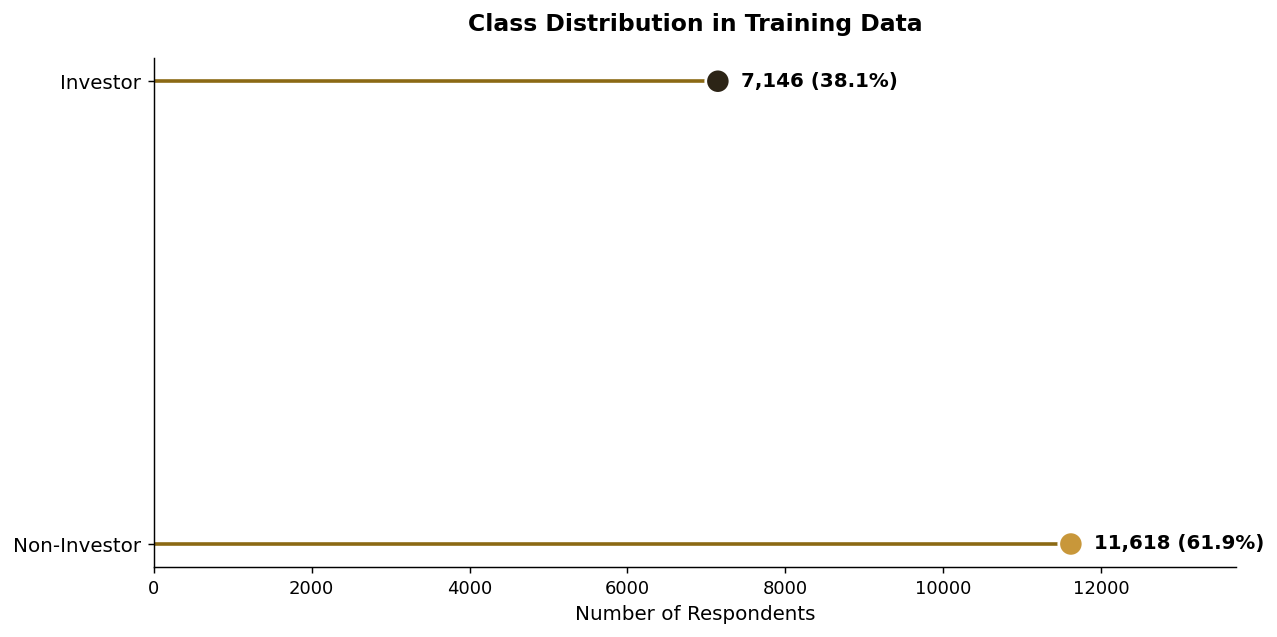

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

categories = ['Non-Investor', 'Investor']
counts = [(y_train == 0).sum(), y_train.sum()]
percentages = [v / len(y_train) * 100 for v in counts]

y_pos = np.arange(len(categories))

ax.hlines(y=y_pos, xmin=0, xmax=counts,
          color=MID, linewidth=2)

ax.scatter(counts, y_pos,
           s=180, color=[GOLD, DARK],
           edgecolor=WHITE, linewidth=1.5,
           zorder=3)

for y, count, pct in zip(y_pos, counts, percentages):
    ax.text(count + max(counts) * 0.025, y,
            f'{count:,} ({pct:.1f}%)',
            va='center',
            fontsize=11,
            fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(categories, fontsize=11)

ax.set_xlabel('Number of Respondents')
ax.set_title(
    'Class Distribution in Training Data',
    fontsize=13,
    fontweight='bold',
    pad=15
)

ax.set_xlim(0, max(counts) * 1.18)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Feature Scaling for Logistic Regression**

In [ ]:
scaler      = StandardScaler()
X_train_sc  = pd.DataFrame(
    scaler.fit_transform(X_train_imp),
    columns=FEATURE_NAMES)
X_test_sc   = pd.DataFrame(
    scaler.transform(X_test_imp),
    columns=FEATURE_NAMES)

**BASELINE MODEL TRAINING**

**Logistic Regression**

In [ ]:
base_lr = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000)

base_lr.fit(X_train_sc, y_train)

print(f" Baseline Logistic Regression trained")

 Baseline Logistic Regression trained


**Random Forest**

In [ ]:
base_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1)

base_rf.fit(X_train_imp, y_train)

print(f" Baseline Random Forest trained")

 Baseline Random Forest trained


**XG Boost**

In [ ]:
base_xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_w,
    verbosity=0,
    tree_method='hist')

base_xgb.fit(X_train_imp, y_train)

print(f" Baseline XGBoost trained")

 Baseline XGBoost trained


**HYPERPARAMETER TUNING**


**Logistic Regression**

In [ ]:
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lr_gs = GridSearchCV(
    LogisticRegression(
        random_state=42,
        class_weight='balanced'),
    {'C':        [0.001, 0.01, 0.1, 1, 10, 100],
     'solver':   ['lbfgs', 'liblinear'],
     'max_iter': [500, 1000]},
    cv=cv_inner, scoring='roc_auc', n_jobs=-1)

lr_gs.fit(X_train_sc, y_train)
best_lr = lr_gs.best_estimator_

print(f" Best params : {lr_gs.best_params_}")
print(f"  CV AUC      : {lr_gs.best_score_:.4f}")

 Best params : {'C': 0.01, 'max_iter': 500, 'solver': 'liblinear'}
  CV AUC      : 0.8341


**Random Forest**

In [ ]:
rf_gs = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=-1),
    {'n_estimators'     : [100, 200, 300],
     'max_depth'        : [5, 10, None],
     'min_samples_split': [2, 5],
     'max_features'     : ['sqrt', 'log2']},
    cv=cv_inner, scoring='roc_auc', n_jobs=-1)

rf_gs.fit(X_train_imp, y_train)
best_rf = rf_gs.best_estimator_

print(f" Best params : {rf_gs.best_params_}")
print(f"  CV AUC      : {rf_gs.best_score_:.4f}")

 Best params : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
  CV AUC      : 0.8338


**XGBoost**

In [ ]:
xgb_gs = RandomizedSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_w,
        verbosity=0,
        tree_method='hist'),
    param_distributions={
        'n_estimators'    : [100, 200, 300, 400, 500],
        'max_depth'       : [3, 4, 5, 6, 7, 8],
        'learning_rate'   : [0.01, 0.03, 0.05, 0.07, 0.1],
        'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        'min_child_weight': [1, 3, 5, 7],
        'gamma'           : [0, 0.1, 0.2, 0.3, 0.5],
        'reg_alpha'       : [0, 0.01, 0.1, 1, 10],
        'reg_lambda'      : [0.1, 1, 5, 10],
    },
    n_iter=100, cv=cv_inner,
    scoring='roc_auc', n_jobs=-1,
    random_state=42, verbose=0)

xgb_gs.fit(X_train_imp, y_train)
best_xgb = xgb_gs.best_estimator_

print(f" Best params : {xgb_gs.best_params_}")
print(f"  CV AUC      : {xgb_gs.best_score_:.4f}")

 Best params : {'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alpha': 10, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.5}
  CV AUC      : 0.8378


**Select Best Model Using CV Score**

In [ ]:
cv_scores = {
    'Logistic Regression': lr_gs.best_score_,
    'Random Forest'      : rf_gs.best_score_,
    'XGBoost'            : xgb_gs.best_score_,
}

best_name = max(cv_scores, key=cv_scores.get)

TRAINED = {
    'Logistic Regression': best_lr,
    'Random Forest'      : best_rf,
    'XGBoost'            : best_xgb,
}

best_model = TRAINED[best_name]

print(f"\nCV AUC scores:")
for name, score in cv_scores.items():
    marker = ' ← BEST' if name == best_name else ''
    print(f"  {name:<25} : {score:.4f}{marker}")

print(f"\n Best model : {best_name}")


CV AUC scores:
  Logistic Regression       : 0.8341
  Random Forest             : 0.8338
  XGBoost                   : 0.8378 ← BEST

 Best model : XGBoost


**Final Model Evaluation on Test Set**

In [ ]:
results = {}
MODEL_NAMES = list(TRAINED.keys())
COLORS_M    = [GOLD, DARK, MID]

for name, model in TRAINED.items():
    X_eval  = X_test_sc if name == 'Logistic Regression' else X_test_imp
    y_pred  = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    results[name] = {
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_test, y_proba),
        'y_pred'   : y_pred,
        'y_proba'  : y_proba,
    }
    print(f"\n{name}:")
    print(classification_report(
        y_test, y_pred,
        target_names=['Non-Investor', 'Investor']))

metrics_df = pd.DataFrame({
    name: {k: v for k, v in m.items()
           if k not in ['y_pred', 'y_proba']}
    for name, m in results.items()
}).T.round(4)

print("\nFinal Performance Summary:")
print(metrics_df.to_string())


Logistic Regression:
              precision    recall  f1-score   support

Non-Investor       0.83      0.71      0.77      2905
    Investor       0.62      0.76      0.68      1787

    accuracy                           0.73      4692
   macro avg       0.73      0.74      0.73      4692
weighted avg       0.75      0.73      0.74      4692


Random Forest:
              precision    recall  f1-score   support

Non-Investor       0.82      0.75      0.78      2905
    Investor       0.64      0.73      0.68      1787

    accuracy                           0.74      4692
   macro avg       0.73      0.74      0.73      4692
weighted avg       0.75      0.74      0.75      4692


XGBoost:
              precision    recall  f1-score   support

Non-Investor       0.84      0.73      0.78      2905
    Investor       0.64      0.77      0.70      1787

    accuracy                           0.74      4692
   macro avg       0.74      0.75      0.74      4692
weighted avg       0.76   

**MODEL COMPARISON**

**Performance Summary Table**

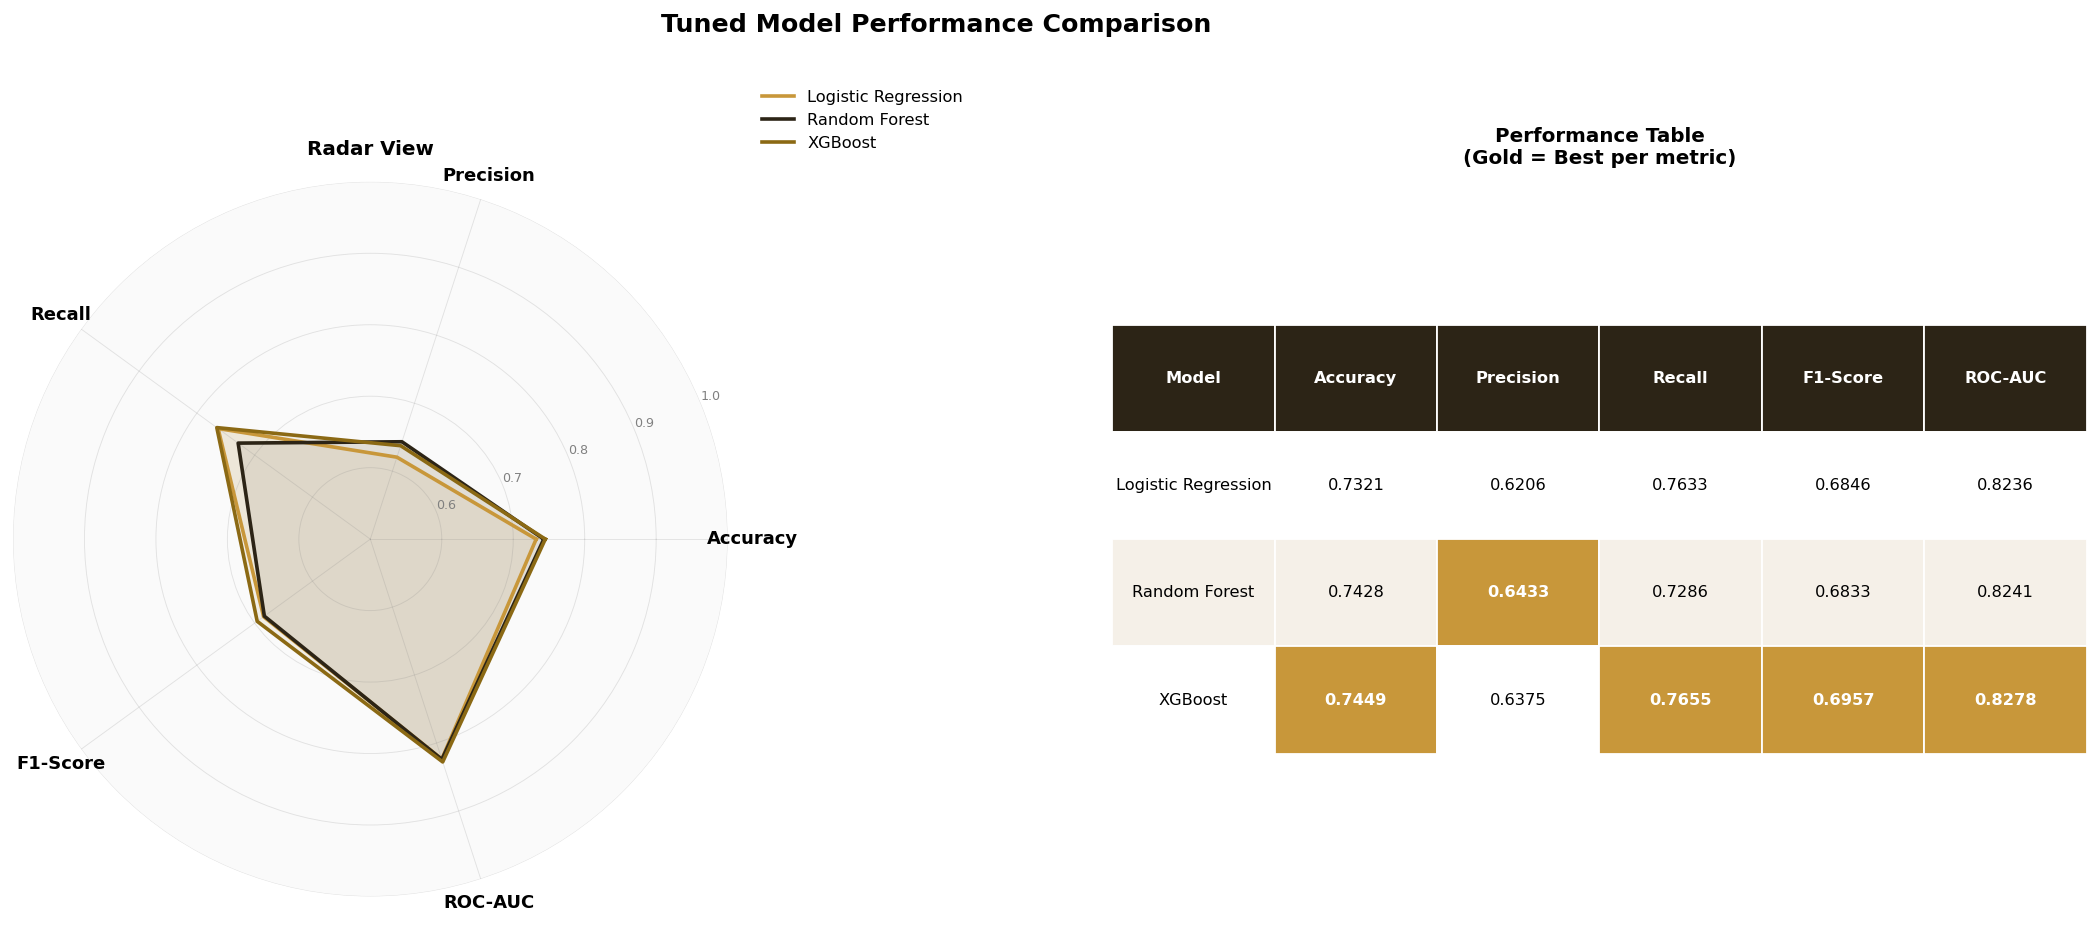

In [ ]:
METRIC_NAMES = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']

fig = plt.figure(figsize=(18, 7))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1])
fig.suptitle('Tuned Model Performance Comparison',
             fontsize=14, fontweight='bold', y=1.01)

ax_r   = fig.add_subplot(gs[0], polar=True)
N      = len(METRIC_NAMES)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]
ax_r.set_facecolor('#FAFAFA')
ax_r.set_ylim(0.5, 1.0)
ax_r.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
ax_r.set_yticklabels(['0.6','0.7','0.8','0.9','1.0'],
                      fontsize=7, color='grey')
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(METRIC_NAMES, fontsize=10, fontweight='bold')
ax_r.grid(color='grey', alpha=0.2, linewidth=0.5)
ax_r.spines['polar'].set_visible(False)
for name, col in zip(MODEL_NAMES, COLORS_M):
    vals  = [results[name][m] for m in METRIC_NAMES]
    vals += vals[:1]
    ax_r.plot(angles, vals, color=col, linewidth=2, label=name)
    ax_r.fill(angles, vals, alpha=0.08, color=col)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
            frameon=False, fontsize=9)
ax_r.set_title('Radar View', fontsize=11, fontweight='bold', pad=15)

ax_t = fig.add_subplot(gs[1])
ax_t.axis('off')
table_data = [[name] + [f"{results[name][m]:.4f}"
               for m in METRIC_NAMES]
              for name in MODEL_NAMES]
tbl = ax_t.table(
    cellText=table_data,
    colLabels=['Model'] + METRIC_NAMES,
    cellLoc='center', loc='center',
    bbox=[0, 0.2, 1, 0.6])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(WHITE)
    if row == 0:
        cell.set_facecolor(DARK)
        cell.set_text_props(color=WHITE, fontweight='bold')
    else:
        cell.set_facecolor('#F5F0E8' if row%2==0 else WHITE)
for ci, metric in enumerate(METRIC_NAMES):
    best_val = max(results[m][metric] for m in MODEL_NAMES)
    for ri, name in enumerate(MODEL_NAMES):
        if abs(results[name][metric] - best_val) < 0.0001:
            tbl[ri+1, ci+1].set_facecolor(GOLD)
            tbl[ri+1, ci+1].set_text_props(color=WHITE, fontweight='bold')
ax_t.set_title('Performance Table\n(Gold = Best per metric)',
               fontsize=11, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

**ROC Curves**

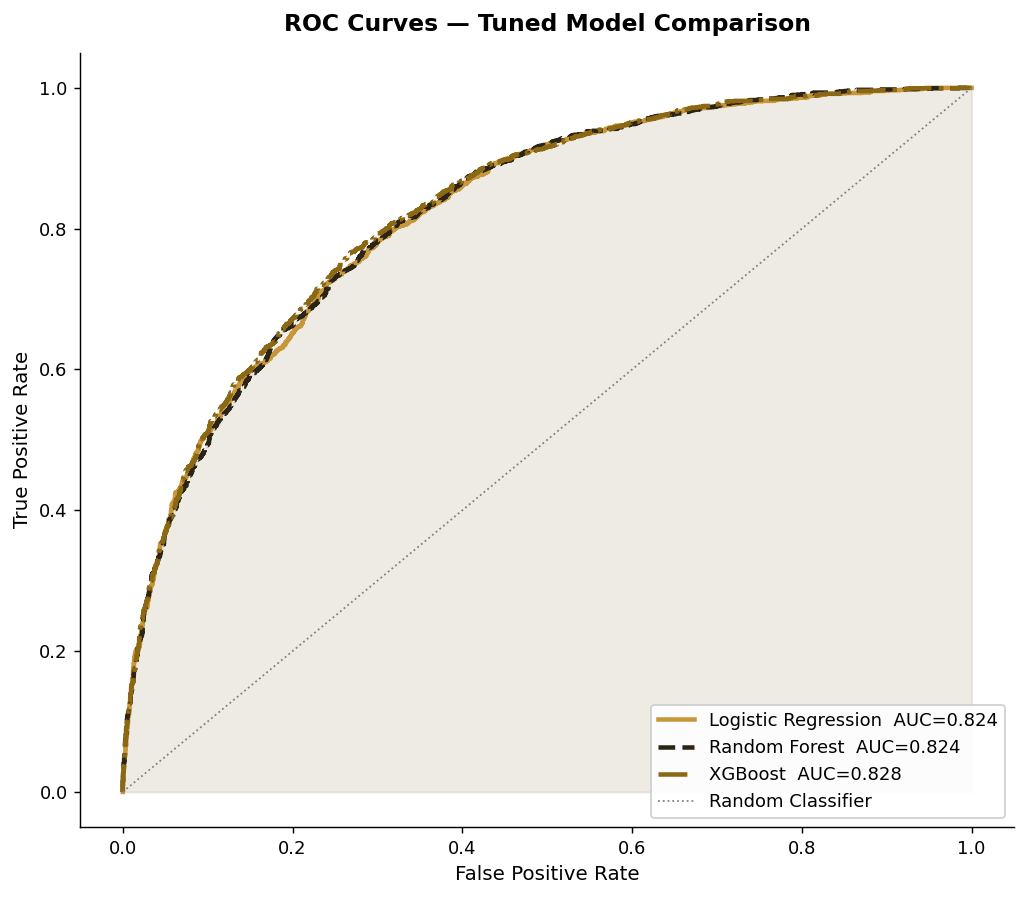

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

for (name, res), col, ls in zip(
        results.items(), COLORS_M, ['-','--','-.']):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=col, lw=2.5, linestyle=ls,
            label=f"{name}  AUC={res['ROC-AUC']:.3f}")
    ax.fill_between(fpr, tpr, alpha=0.04, color=col)

ax.plot([0,1],[0,1], color='grey', lw=1,
        linestyle=':', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Tuned Model Comparison',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='lower right',
          frameon=True, framealpha=0.9)

plt.tight_layout()
plt.show()

**Confusion Matrices**

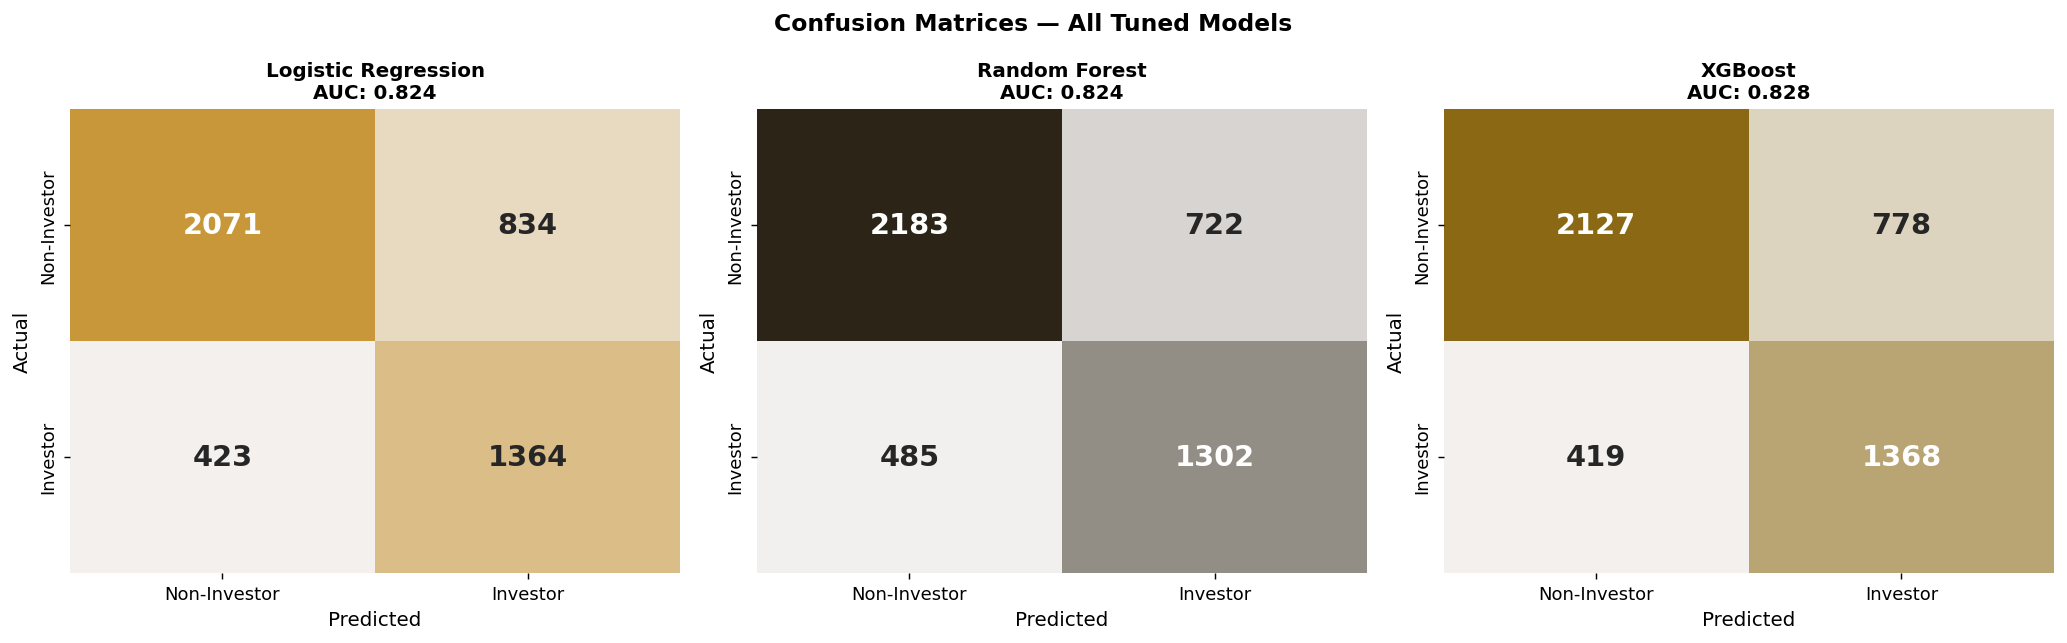

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices — All Tuned Models',
             fontsize=13, fontweight='bold')

cmaps = [sns.light_palette(c, as_cmap=True)
         for c in [GOLD, DARK, MID]]

for ax, (name, res), cmap in zip(axes, results.items(), cmaps):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                ax=ax,
                xticklabels=['Non-Investor', 'Investor'],
                yticklabels=['Non-Investor', 'Investor'],
                linewidths=0, cbar=False,
                annot_kws={'size': 16, 'weight': 'bold'})
    ax.set_title(f'{name}\nAUC: {res["ROC-AUC"]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

**Cross-Validation**

5-Fold Stratified Cross-Validation (ROC-AUC):
Logistic Regression       AUC: 0.822 ± 0.011
Random Forest             AUC: 0.819 ± 0.007
XGBoost                   AUC: 0.822 ± 0.009


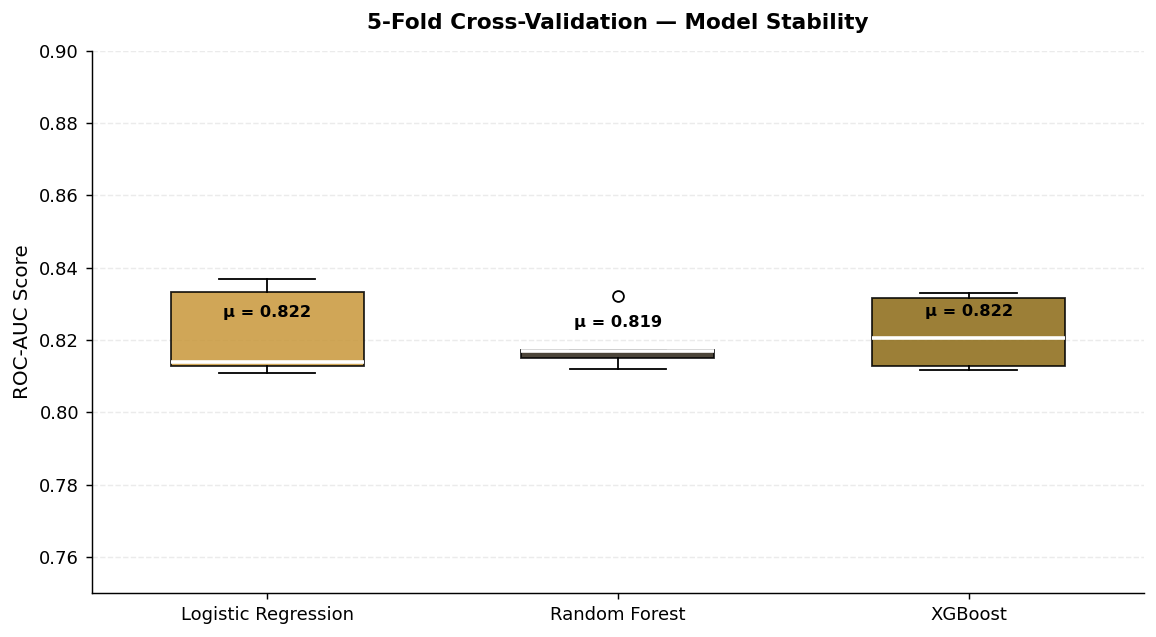

In [ ]:
cv_outer = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_res = {}

print("5-Fold Stratified Cross-Validation (ROC-AUC):")

for name, model in TRAINED.items():

    X_cv = X_test_sc if name == 'Logistic Regression' else X_test_imp

    scores = cross_val_score(
        model,
        X_cv,
        y_test,
        cv=cv_outer,
        scoring='roc_auc',
        n_jobs=-1
    )

    cv_res[name] = scores

    print(
        f"{name:<25} "
        f"AUC: {scores.mean():.3f} ± {scores.std():.3f}"
    )

fig, ax = plt.subplots(figsize=(9, 5))

bp = ax.boxplot(
    [cv_res[m] for m in MODEL_NAMES],
    labels=MODEL_NAMES,
    patch_artist=True,
    widths=0.55,
    medianprops=dict(
        color=WHITE,
        linewidth=2
    )
)

for patch, col in zip(bp['boxes'], COLORS_M):
    patch.set_facecolor(col)
    patch.set_alpha(0.85)

for i, name in enumerate(MODEL_NAMES, start=1):
    mean_val = cv_res[name].mean()

    ax.text(
        i,
        mean_val + 0.004,
        f'μ = {mean_val:.3f}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax.set_ylabel('ROC-AUC Score', fontsize=11)

ax.set_title(
    '5-Fold Cross-Validation — Model Stability',
    fontsize=12,
    fontweight='bold',
    pad=12
)

ax.set_ylim(0.75, 0.90)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.25
)

plt.tight_layout()
plt.show()

**NON-INVESTOR PROPENSITY ANALYSIS**

**Propensity Scoring**

In [ ]:
non_inv_mask = (y_test.values == 0)
X_non_inv    = X_test_imp[non_inv_mask].copy().reset_index(drop=True)
X_non_inv_sc = X_test_sc[non_inv_mask].copy().reset_index(drop=True)

X_ni_eval = (X_non_inv_sc
             if best_name == 'Logistic Regression'
             else X_non_inv)

propensity_scores = best_model.predict_proba(X_ni_eval)[:, 1]
X_non_inv['Propensity_Score'] = propensity_scores

X_non_inv['Propensity_Group'] = pd.cut(
    X_non_inv['Propensity_Score'],
    bins=[0, 0.35, 0.65, 1.0],
    labels=['Low Propensity',
            'Medium Propensity',
            'High Propensity'])

n_ni   = len(X_non_inv)
high_c = (X_non_inv['Propensity_Group']=='High Propensity').sum()
med_c  = (X_non_inv['Propensity_Group']=='Medium Propensity').sum()
low_c  = (X_non_inv['Propensity_Group']=='Low Propensity').sum()

print(f"\nNon-investors in test set : {n_ni:,}")
print(f"Mean propensity score     : {propensity_scores.mean():.3f}")
print(f"Max propensity score      : {propensity_scores.max():.3f}")
print(f"\nPropensity Groups:")
print(f"  High   (≥0.65) : {high_c:,} ({high_c/n_ni*100:.1f}%)")
print(f"  Medium         : {med_c:,}  ({med_c/n_ni*100:.1f}%)")
print(f"  Low    (<0.35) : {low_c:,}  ({low_c/n_ni*100:.1f}%)")


Non-investors in test set : 2,905
Mean propensity score     : 0.338
Max propensity score      : 0.957

Propensity Groups:
  High   (≥0.65) : 437 (15.0%)
  Medium         : 761  (26.2%)
  Low    (<0.35) : 1,707  (58.8%)


**Propensity Distribution Visualisation**



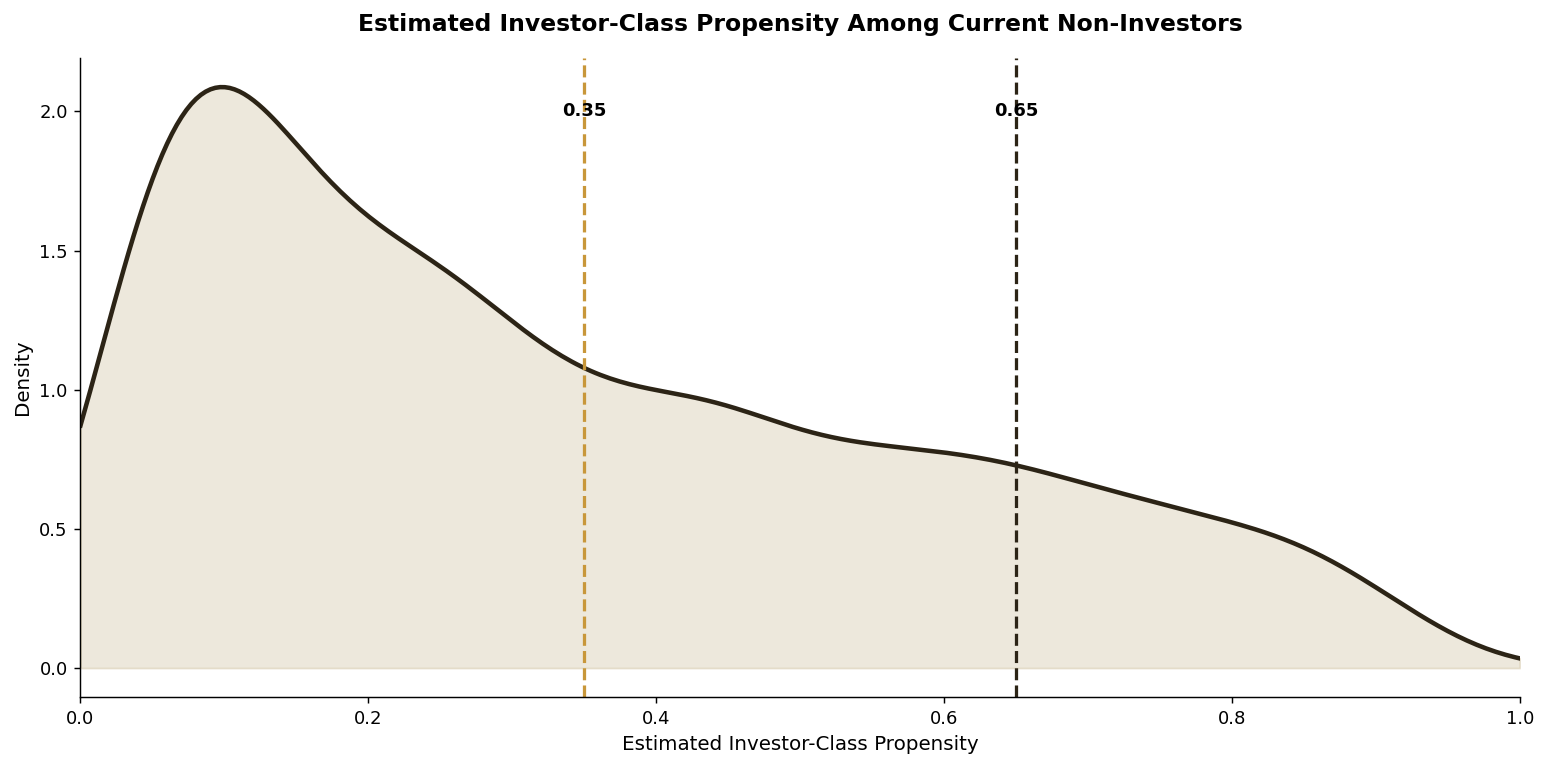

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

kde = gaussian_kde(propensity_scores, bw_method=0.2)
x_range = np.linspace(0, 1, 300)
density = kde(x_range)

ax.plot(
    x_range,
    density,
    color=DARK,
    linewidth=2.5
)

ax.fill_between(
    x_range,
    density,
    alpha=0.15,
    color=MID
)

ax.axvline(
    0.35,
    color=GOLD,
    linestyle='--',
    linewidth=1.8
)

ax.axvline(
    0.65,
    color=DARK,
    linestyle='--',
    linewidth=1.8
)

ax.text(
    0.35,
    max(density) * 0.95,
    '0.35',
    ha='center',
    fontsize=10,
    fontweight='bold'
)

ax.text(
    0.65,
    max(density) * 0.95,
    '0.65',
    ha='center',
    fontsize=10,
    fontweight='bold'
)

ax.set_xlim(0, 1)

ax.set_xlabel('Estimated Investor-Class Propensity')
ax.set_ylabel('Density')

ax.set_title(
    'Estimated Investor-Class Propensity Among Current Non-Investors',
    fontsize=13,
    fontweight='bold',
    pad=15
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Propensity Dashboard**

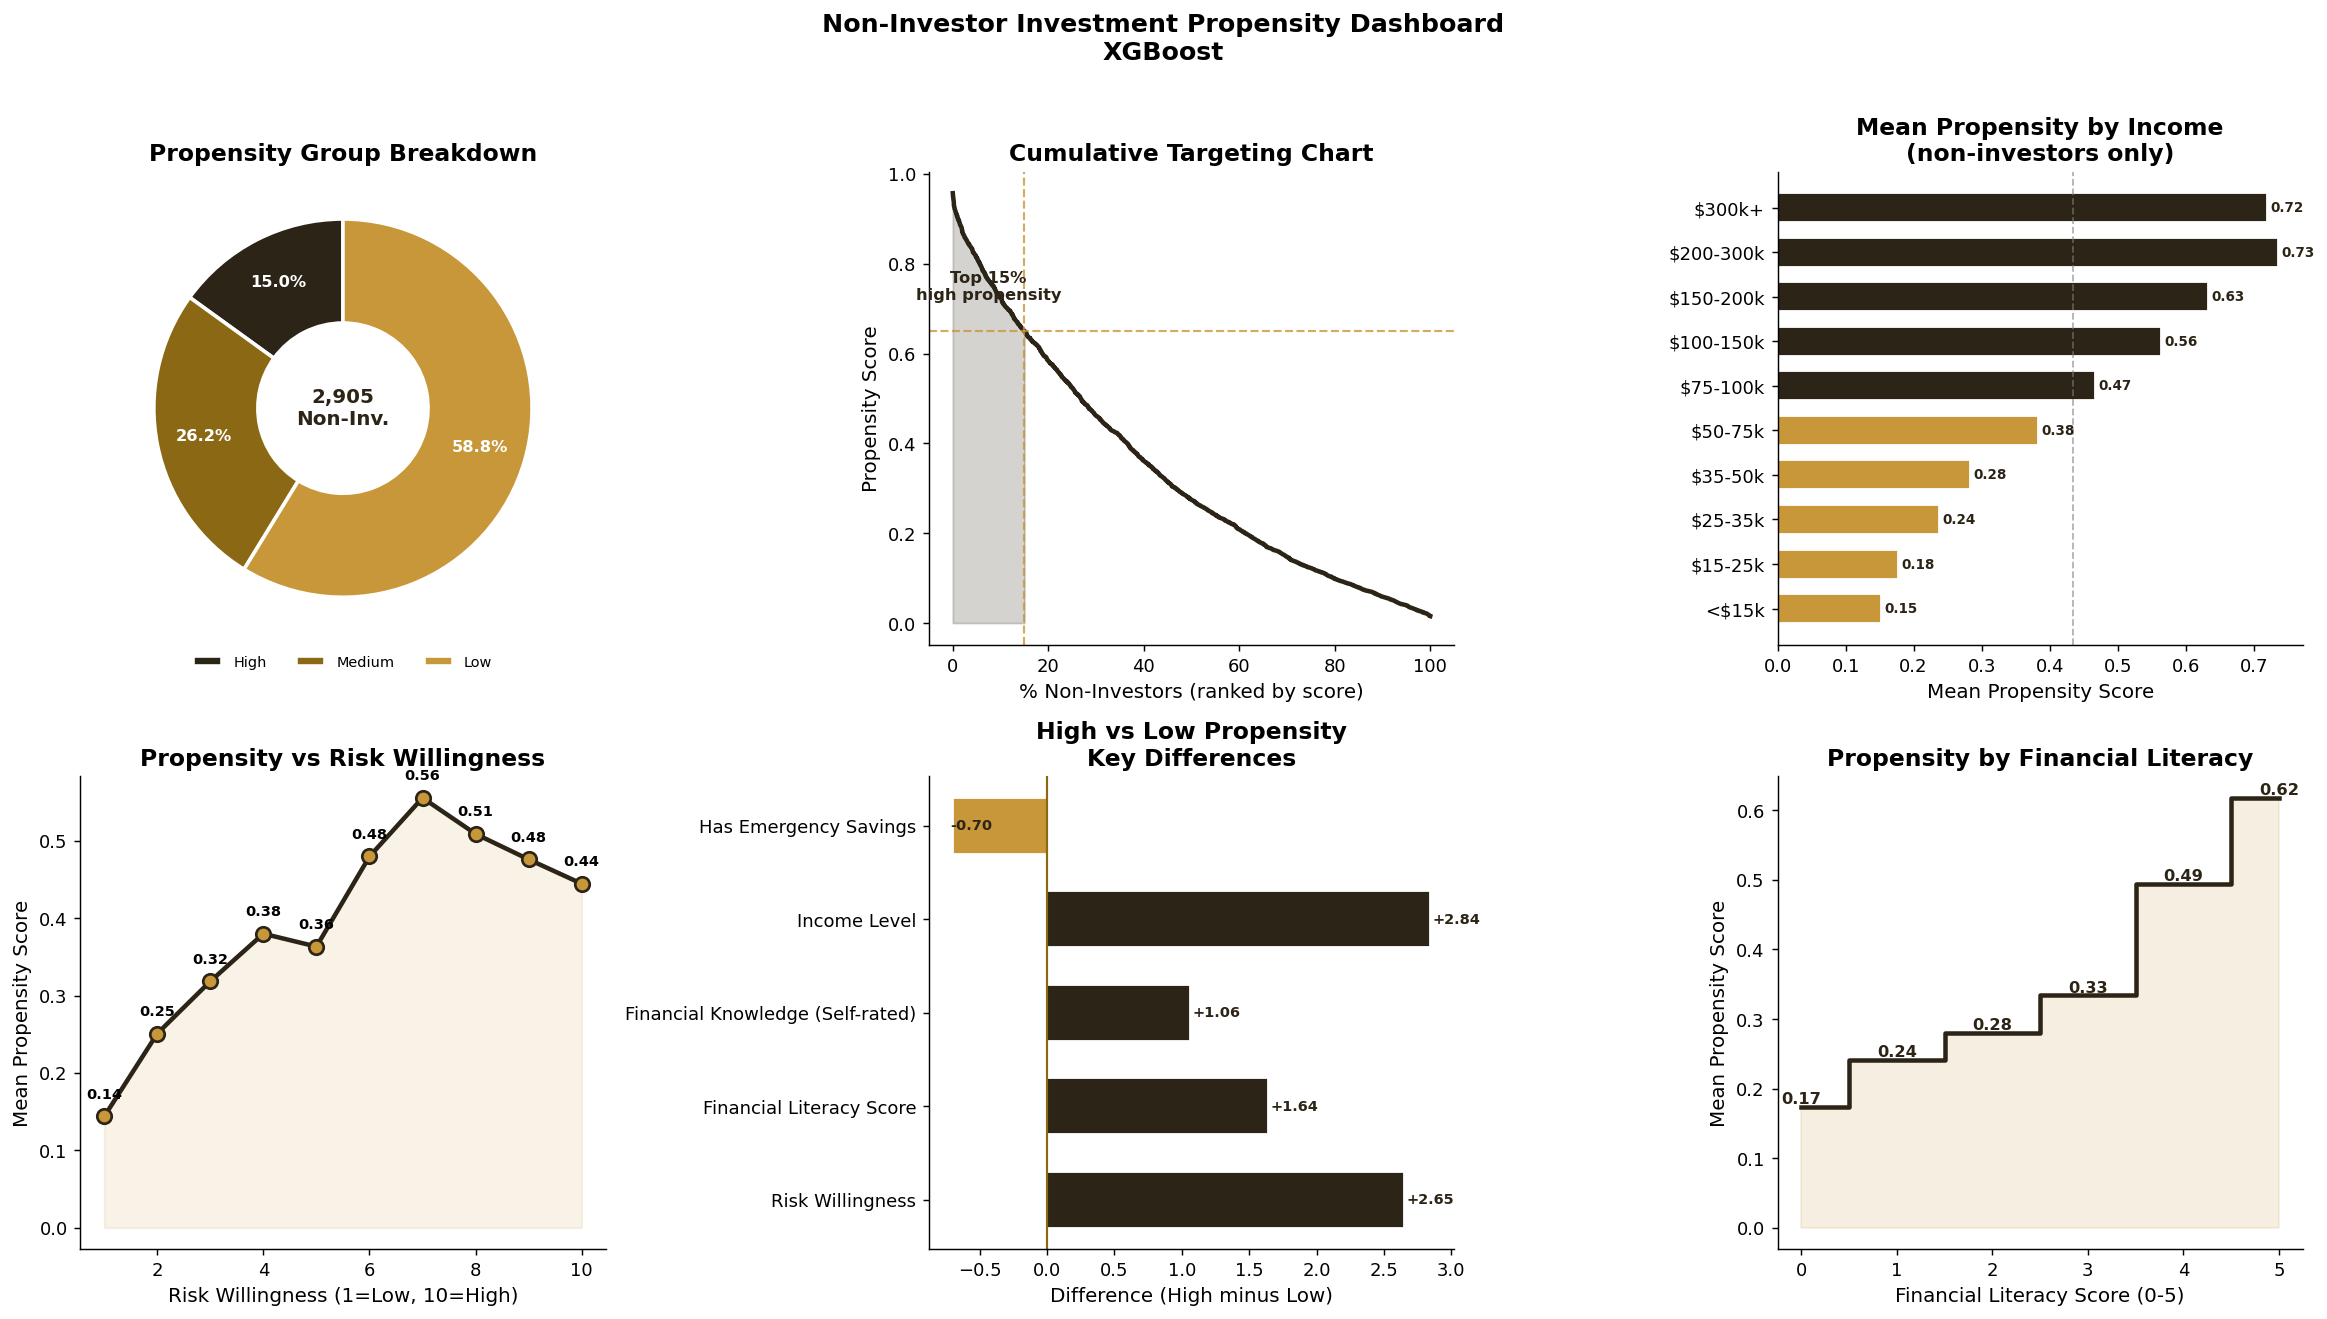

In [ ]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle('Non-Investor Investment Propensity Dashboard\n'
             f'{best_name}',
             fontsize=14, fontweight='bold', y=1.01)

#propensity group breakdown
ax1 = fig.add_subplot(2, 3, 1)
grp_vals = [high_c, med_c, low_c]
grp_cols = [DARK, MID, GOLD]
grp_lbls = ['High', 'Medium', 'Low']
wedges, texts, autotexts = ax1.pie(
    grp_vals, colors=grp_cols,
    autopct='%1.1f%%', startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor=WHITE, linewidth=2),
    textprops={'fontsize': 9})
for at in autotexts:
    at.set_color(WHITE); at.set_fontweight('bold')
ax1.text(0, 0, f'{n_ni:,}\nNon-Inv.',
         ha='center', va='center',
         fontsize=11, fontweight='bold', color=DARK)
ax1.legend(grp_lbls, loc='lower center',
           bbox_to_anchor=(0.5, -0.08),
           ncol=3, frameon=False, fontsize=8)
ax1.set_title('Propensity Group Breakdown', fontweight='bold')

#cumulative targeting
ax2 = fig.add_subplot(2, 3, 2)
sorted_s = np.sort(propensity_scores)[::-1]
cum_pct  = np.arange(1, len(sorted_s)+1)/len(sorted_s)*100
high_pct = (propensity_scores >= 0.65).mean()*100
ax2.plot(cum_pct, sorted_s, color=DARK, linewidth=2.5)
ax2.fill_between(cum_pct, sorted_s,
                 where=(sorted_s >= 0.65),
                 alpha=0.2, color=DARK)
ax2.axhline(0.65, color=GOLD, linestyle='--',
            linewidth=1.2, alpha=0.8)
ax2.axvline(high_pct, color=GOLD, linestyle='--',
            linewidth=1.2, alpha=0.8)
ax2.text(high_pct/2, 0.72,
         f'Top {high_pct:.0f}%\nhigh propensity',
         ha='center', fontsize=9,
         color=DARK, fontweight='bold')
ax2.set_xlabel('% Non-Investors (ranked by score)')
ax2.set_ylabel('Propensity Score')
ax2.set_title('Cumulative Targeting Chart',
              fontweight='bold')

# Propensity by income
ax3 = fig.add_subplot(2, 3, 3)
inc_prop  = X_non_inv.groupby(
    'Income Level')['Propensity_Score'].mean()
inc_lab2  = {1:'<$15k', 2:'$15-25k', 3:'$25-35k',
             4:'$35-50k', 5:'$50-75k', 6:'$75-100k',
             7:'$100-150k', 8:'$150-200k',
             9:'$200-300k', 10:'$300k+'}
inc_prop.index = [inc_lab2.get(int(i), str(i))
                  for i in inc_prop.index]
col_ip = [DARK if v > inc_prop.mean() else GOLD
          for v in inc_prop.values]
ax3.barh(inc_prop.index, inc_prop.values,
         color=col_ip, edgecolor=WHITE, height=0.65)
ax3.axvline(inc_prop.mean(), color='grey',
            linestyle='--', linewidth=1, alpha=0.6)
ax3.set_xlabel('Mean Propensity Score')
ax3.set_title('Mean Propensity by Income\n(non-investors only)',
              fontweight='bold')
for i, v in enumerate(inc_prop.values):
    ax3.text(v+0.005, i, f'{v:.2f}', va='center',
             fontsize=7.5, fontweight='bold', color=DARK)

# Risk willingness
ax4 = fig.add_subplot(2, 3, 4)
risk_prop = X_non_inv.groupby(
    'Risk Willingness')['Propensity_Score'].mean()
ax4.plot(risk_prop.index, risk_prop.values,
         color=DARK, linewidth=2.5, marker='o',
         markersize=8, markerfacecolor=GOLD,
         markeredgecolor=DARK, markeredgewidth=1.5)
ax4.fill_between(risk_prop.index, risk_prop.values,
                 alpha=0.12, color=GOLD)
for x, y in zip(risk_prop.index, risk_prop.values):
    ax4.annotate(f'{y:.2f}', (x, y),
                 xytext=(0, 10),
                 textcoords='offset points',
                 ha='center', fontsize=8,
                 fontweight='bold')
ax4.set_xlabel('Risk Willingness (1=Low, 10=High)')
ax4.set_ylabel('Mean Propensity Score')
ax4.set_title('Propensity vs Risk Willingness',
              fontweight='bold')

# High vs Low differences
ax5 = fig.add_subplot(2, 3, 5)
high_grp  = X_non_inv[
    X_non_inv['Propensity_Group']=='High Propensity']
low_grp   = X_non_inv[
    X_non_inv['Propensity_Group']=='Low Propensity']
cmp_feats = ['Risk Willingness', 'Financial Literacy Score',
             'Financial Knowledge (Self-rated)',
             'Income Level', 'Has Emergency Savings']
cmp_feats = [f for f in cmp_feats if f in X_non_inv.columns]
diff      = high_grp[cmp_feats].mean() - low_grp[cmp_feats].mean()
col_diff  = [DARK if v >= 0 else GOLD for v in diff.values]
ax5.barh(cmp_feats, diff.values, color=col_diff,
         edgecolor=WHITE, height=0.6)
ax5.axvline(0, color=MID, linewidth=1.2)
ax5.set_xlabel('Difference (High minus Low)')
ax5.set_title('High vs Low Propensity\nKey Differences',
              fontweight='bold')
for i, v in enumerate(diff.values):
    xp = v+0.02 if v >= 0 else v-0.02
    ha = 'left' if v >= 0 else 'right'
    ax5.text(xp, i, f'{v:+.2f}', va='center',
             fontsize=8, fontweight='bold', color=DARK)

# Propensity by literacy
ax6 = fig.add_subplot(2, 3, 6)
lit_prop = X_non_inv.groupby(
    'Financial Literacy Score')['Propensity_Score'].mean()
ax6.step(lit_prop.index, lit_prop.values,
         where='mid', color=DARK, linewidth=2.5)
ax6.fill_between(lit_prop.index, lit_prop.values,
                 step='mid', alpha=0.15, color=GOLD)
for idx, v in lit_prop.items():
    ax6.text(idx, v+0.005, f'{v:.2f}',
             ha='center', fontsize=9,
             fontweight='bold', color=DARK)
ax6.set_xlabel('Financial Literacy Score (0-5)')
ax6.set_ylabel('Mean Propensity Score')
ax6.set_title('Propensity by Financial Literacy',
              fontweight='bold')
ax6.set_xticks([0,1,2,3,4,5])

plt.tight_layout()
plt.show()

**SHAP EXPLAINABILITY**

**Compute SHAP Values**

In [ ]:
X_best = X_test_sc if best_name == 'Logistic Regression' else X_test_imp

if best_name == 'Logistic Regression':
    explainer = shap.LinearExplainer(best_model, X_train_sc)
    sv        = explainer(X_best)
else:
    explainer = shap.TreeExplainer(best_model)
    sv        = explainer(X_best)
    if hasattr(sv,'values') and len(sv.values.shape)==3:
        sv = sv[:,:,1]

print(f" SHAP values computed")
print(f"  Shape : {sv.values.shape}")

 SHAP values computed
  Shape : (4692, 16)


**Global Feature Importance**

  **Beeswarm Plot**

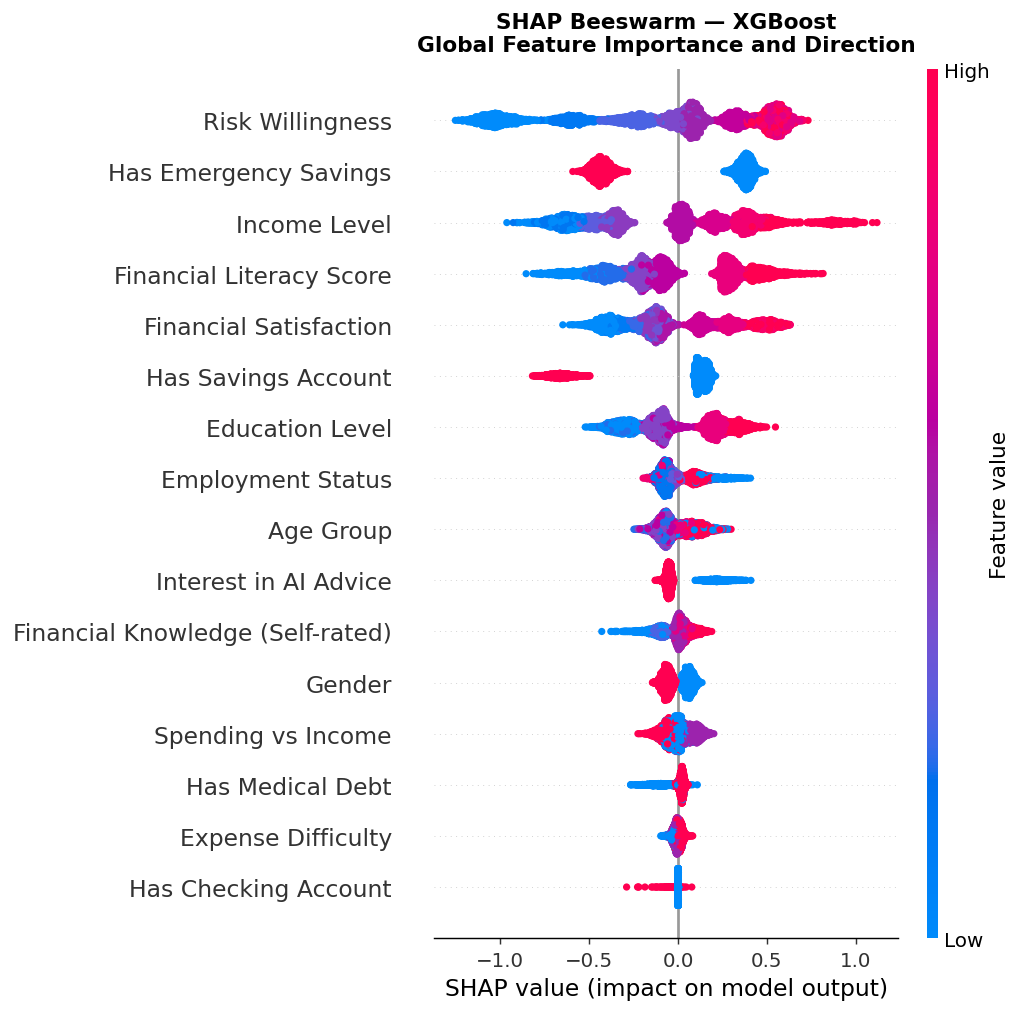

In [ ]:
fig, ax = plt.subplots(figsize=(11, 8))
shap.summary_plot(sv, X_best, plot_type='dot', show=False)
plt.title(f'SHAP Beeswarm — {best_name}\n'
          'Global Feature Importance and Direction',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

**Custom SHAP Importance**

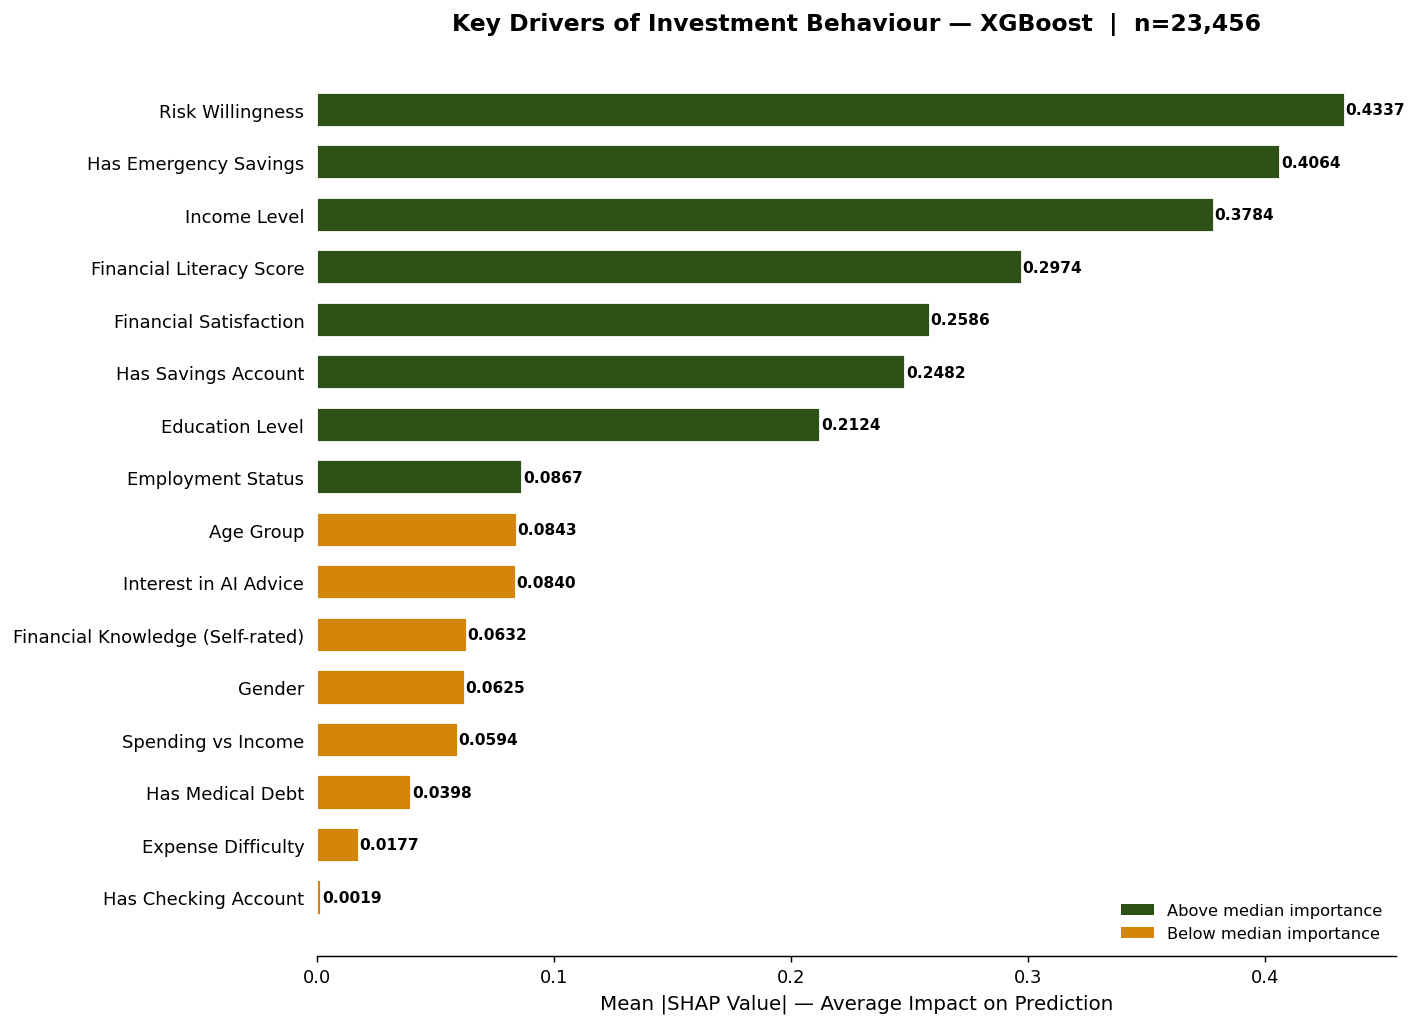


Top 5 features:
                 Feature  Mean |SHAP|
        Risk Willingness     0.433741
   Has Emergency Savings     0.406430
            Income Level     0.378404
Financial Literacy Score     0.297362
  Financial Satisfaction     0.258647


In [ ]:
shap_imp = pd.DataFrame({
    'Feature'     : FEATURE_NAMES,
    'Mean |SHAP|' : np.abs(sv.values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))
colors_si = ['#2D5016' if v >= shap_imp['Mean |SHAP|'].median()
             else '#D4860A' for v in shap_imp['Mean |SHAP|']]
bars = ax.barh(shap_imp['Feature'], shap_imp['Mean |SHAP|'],
               color=colors_si, edgecolor=WHITE, height=0.65)
for bar, v in zip(bars, shap_imp['Mean |SHAP|']):
    ax.text(v+0.0003, bar.get_y()+bar.get_height()/2,
            f'{v:.4f}', va='center',
            fontsize=8.5, fontweight='bold')
ax.set_xlabel('Mean |SHAP Value| — Average Impact on Prediction')
ax.set_title(f'Key Drivers of Investment Behaviour — {best_name}  |  n={total:,}',
             fontsize=13, fontweight='bold', pad=12)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)
legend_els = [
    mpatches.Patch(facecolor='#2D5016', label='Above median importance'),
    mpatches.Patch(facecolor='#D4860A', label='Below median importance')]
ax.legend(handles=legend_els, frameon=False,
          fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(shap_imp.sort_values('Mean |SHAP|', ascending=False)
      .head(5).to_string(index=False))

**INDIVIDUAL LEVEL**

**Waterfall Plot — Investor**

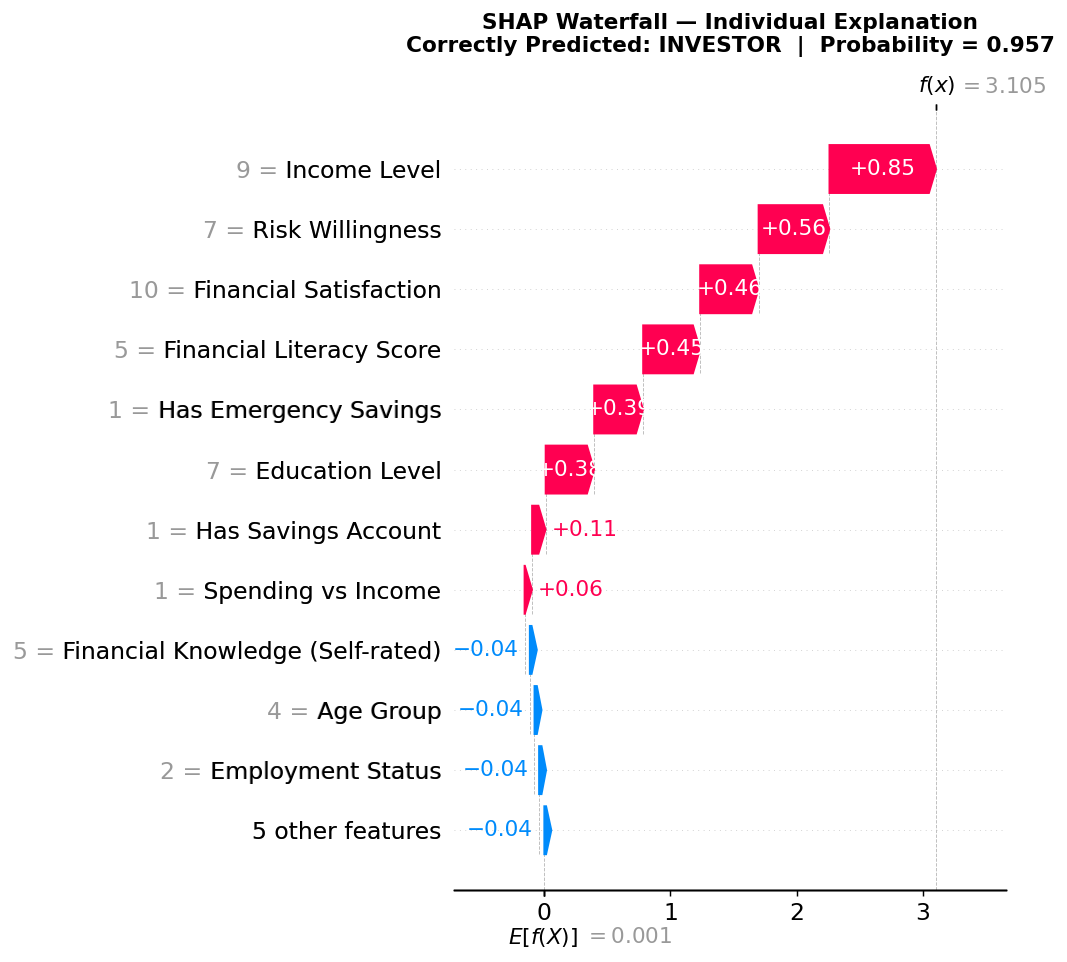

In [ ]:
y_pred_arr  = results[best_name]['y_pred']
inv_idx     = np.where((y_test.values==1) & (y_pred_arr==1))[0]
non_inv_idx = np.where((y_test.values==0) & (y_pred_arr==0))[0]

fig, ax = plt.subplots(figsize=(12, 7))
shap.waterfall_plot(sv[int(inv_idx[0])],
                    show=False, max_display=12)
plt.title('SHAP Waterfall — Individual Explanation\n'
          f'Correctly Predicted: INVESTOR  |  '
          f'Probability = '
          f'{results[best_name]["y_proba"][int(inv_idx[0])]:.3f}',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

**Waterfall Plot — Non-Investor**

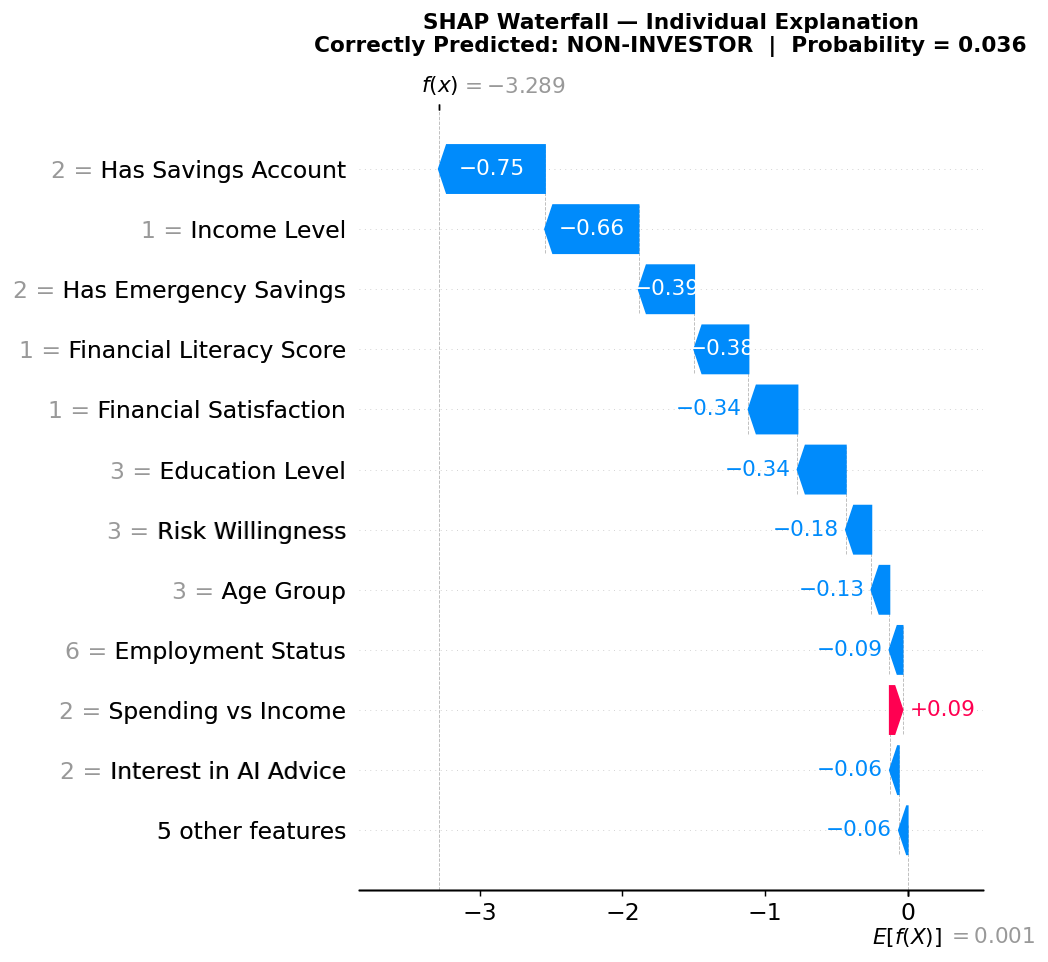

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
shap.waterfall_plot(sv[int(non_inv_idx[0])],
                    show=False, max_display=12)
plt.title('SHAP Waterfall — Individual Explanation\n'
          f'Correctly Predicted: NON-INVESTOR  |  '
          f'Probability = '
          f'{results[best_name]["y_proba"][int(non_inv_idx[0])]:.3f}',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

**DIRECTIONAL ANALYSIS**

**Dependence Plots — Top 3 Features**

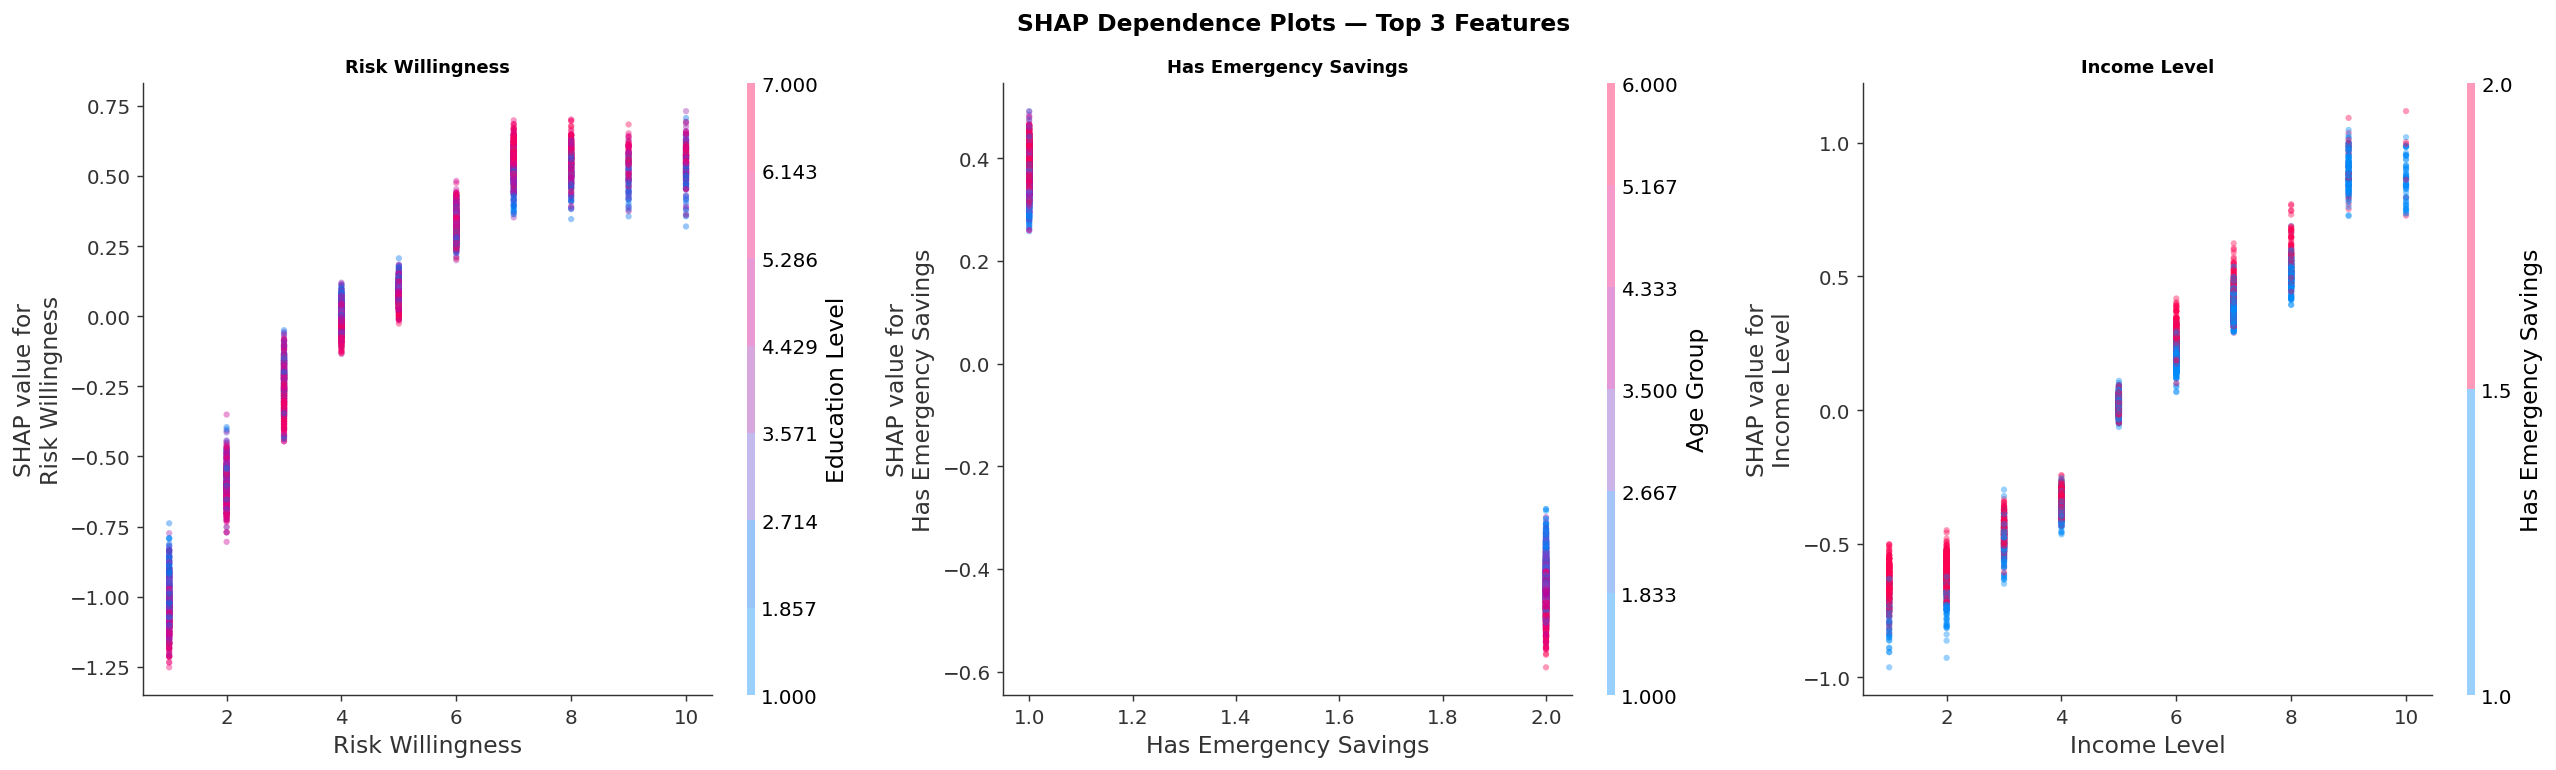

In [ ]:
top3 = shap_imp.sort_values(
    'Mean |SHAP|', ascending=False)['Feature'].tolist()[:3]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('SHAP Dependence Plots — Top 3 Features',
             fontsize=13, fontweight='bold')

for ax, feat in zip(axes, top3):
    idx = list(X_best.columns).index(feat)
    shap.dependence_plot(idx, sv.values, X_best,
                         ax=ax, show=False,
                         dot_size=12, alpha=0.4)
    ax.set_title(feat, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**PREDICTION PATHWAY**

**Decision plot - Investot vs Non-Invetsor prediction pathways**

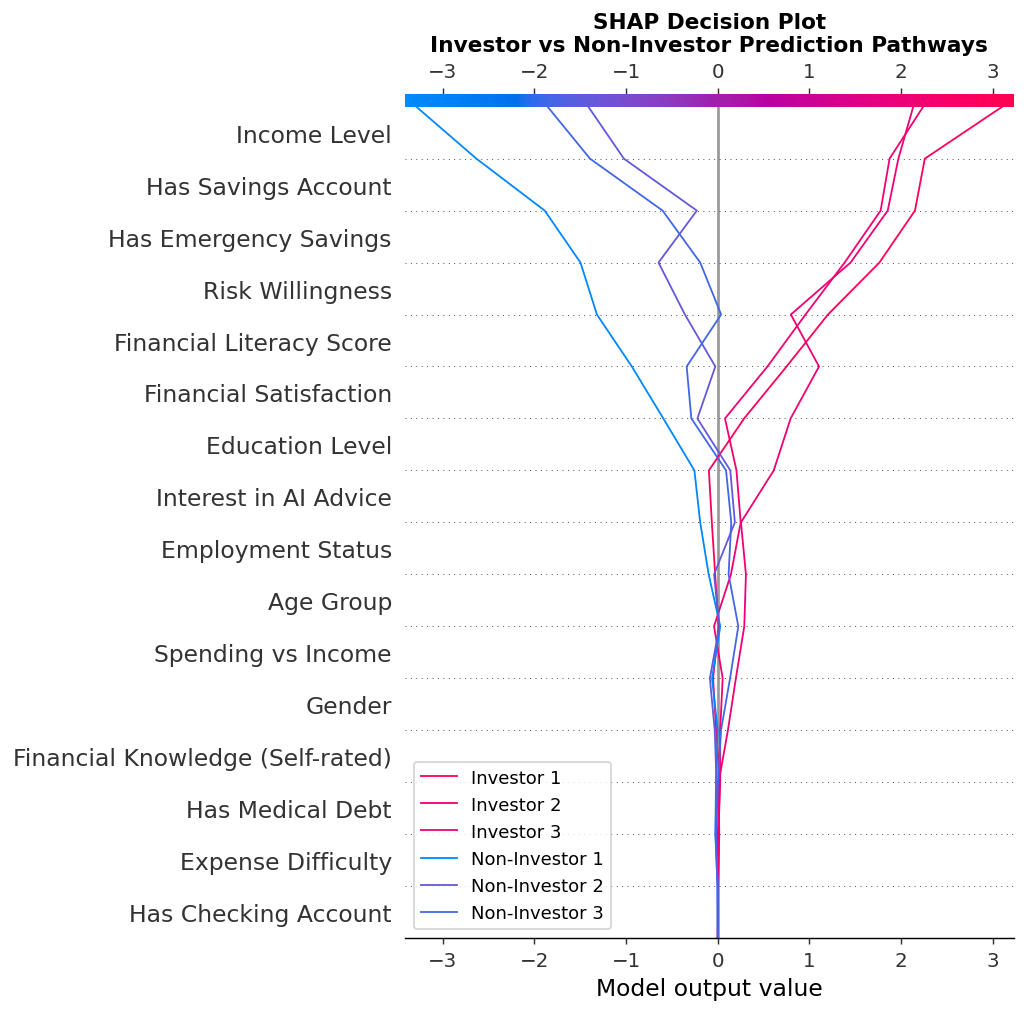

In [ ]:
sample_idx = list(inv_idx[:3]) + list(non_inv_idx[:3])

expected_val = explainer.expected_value
if hasattr(expected_val, '__len__'):
    expected_val = expected_val[1]

fig, ax = plt.subplots(figsize=(13, 9))
shap.decision_plot(
    expected_val,
    sv.values[sample_idx],
    X_best.iloc[sample_idx],
    feature_display_range=slice(None, -len(FEATURE_NAMES)-1, -1),
    show=False,
    legend_labels=['Investor 1', 'Investor 2', 'Investor 3',
                   'Non-Investor 1', 'Non-Investor 2',
                   'Non-Investor 3'])
plt.title('SHAP Decision Plot\n'
          'Investor vs Non-Investor Prediction Pathways',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**PARTIAL DEPENDENCE PLOTS**

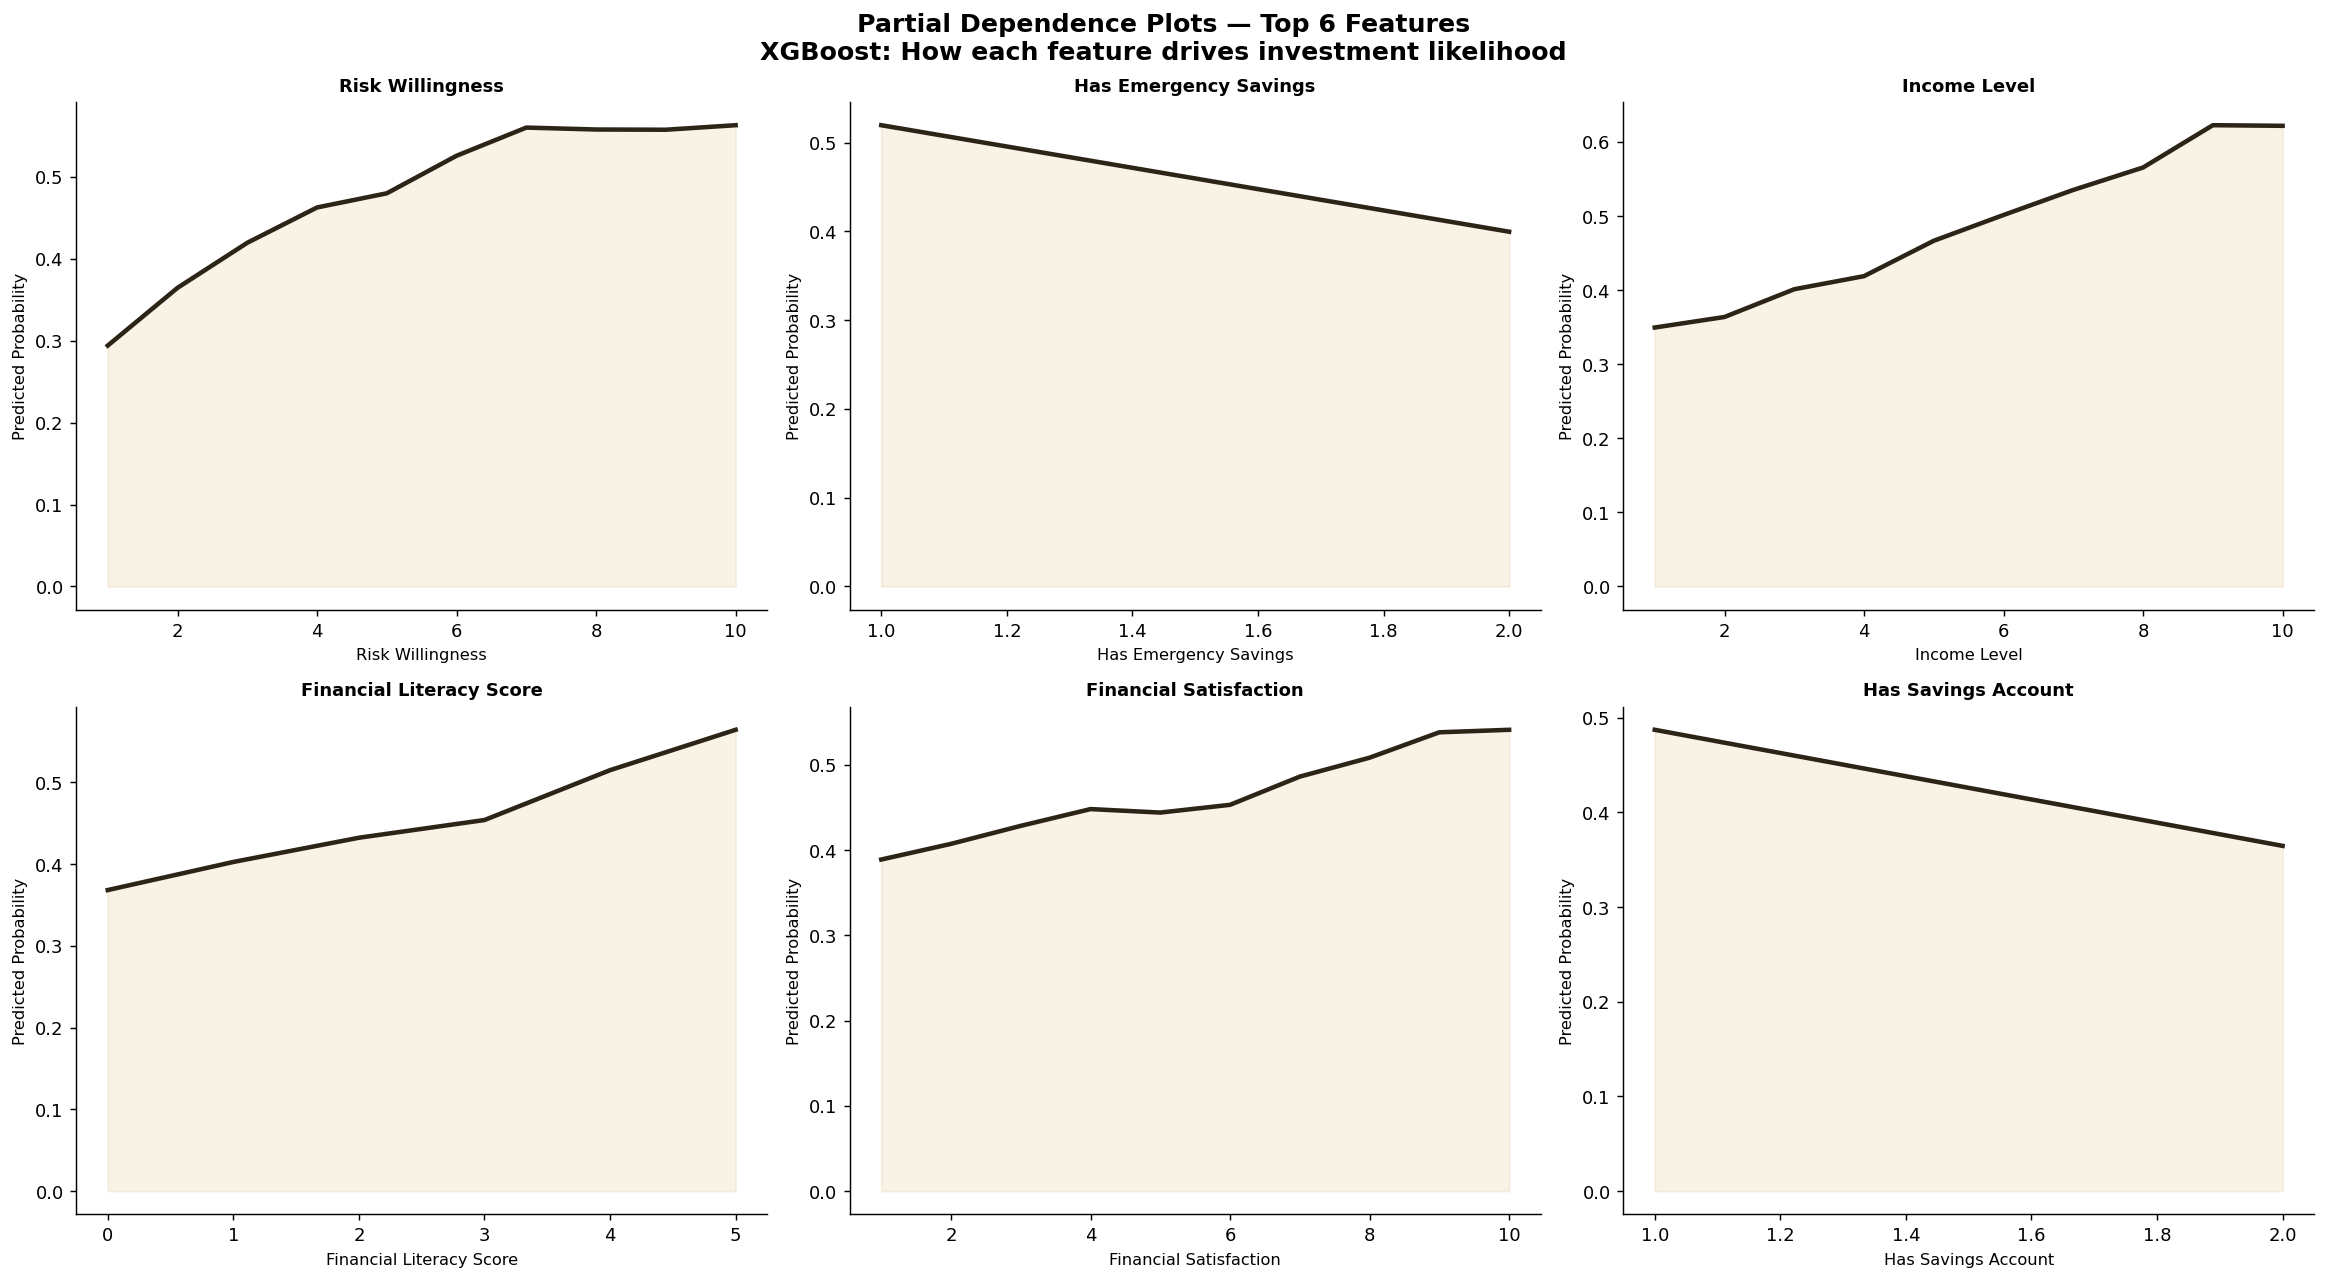

 PDP complete


In [ ]:
top6 = shap_imp.sort_values(
    'Mean |SHAP|', ascending=False)['Feature'].tolist()[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Partial Dependence Plots — Top 6 Features\n'
             f'{best_name}: How each feature drives '
             f'investment likelihood',
             fontsize=14, fontweight='bold')

for ax, fname in zip(axes.flatten(), top6):
    feat_vals = np.sort(X_best[fname].unique())
    pdp_vals  = []
    for val in feat_vals:
        X_temp        = X_best.copy()
        X_temp[fname] = val
        proba = best_model.predict_proba(X_temp)[:,1].mean()
        pdp_vals.append(proba)
    ax.plot(feat_vals, pdp_vals,
            color=DARK, linewidth=2.5)
    ax.fill_between(feat_vals, pdp_vals,
                    alpha=0.12, color=GOLD)
    ax.set_title(fname, fontsize=10, fontweight='bold')
    ax.set_xlabel(fname, fontsize=9)
    ax.set_ylabel('Predicted Probability', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
print(" PDP complete")

**SHAP ON NON-INVESTORS**

**Compute SHAP Values for Non-Investors**

In [ ]:
X_ni_shap = (X_non_inv_sc
             if best_name == 'Logistic Regression'
             else X_non_inv)
X_ni_shap = X_ni_shap[FEATURE_NAMES].copy()

if best_name == 'Logistic Regression':
    sv_ni = explainer(X_ni_shap)
else:
    sv_ni = explainer(X_ni_shap)
    if hasattr(sv_ni,'values') and len(sv_ni.values.shape)==3:
        sv_ni = sv_ni[:,:,1]

print(f" SHAP values computed for {len(X_ni_shap):,} non-investors")

 SHAP values computed for 2,905 non-investors


**Non-Investor Beeswarm Plot**

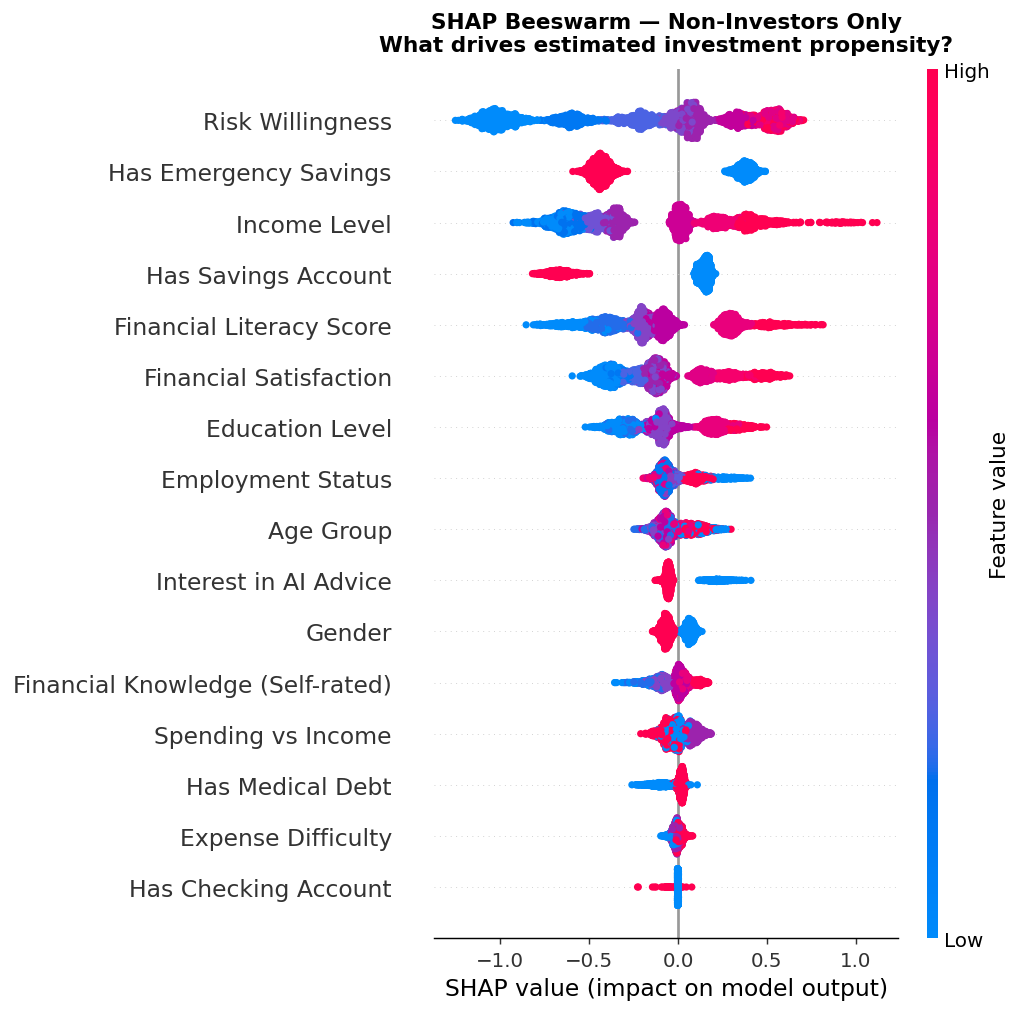

In [ ]:
fig, ax = plt.subplots(figsize=(11, 8))
shap.summary_plot(sv_ni, X_ni_shap, plot_type='dot', show=False)
plt.title(f'SHAP Beeswarm — Non-Investors Only\n'
          'What drives estimated investment propensity?',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

**High vs Low Propensity SHAP Comparison**

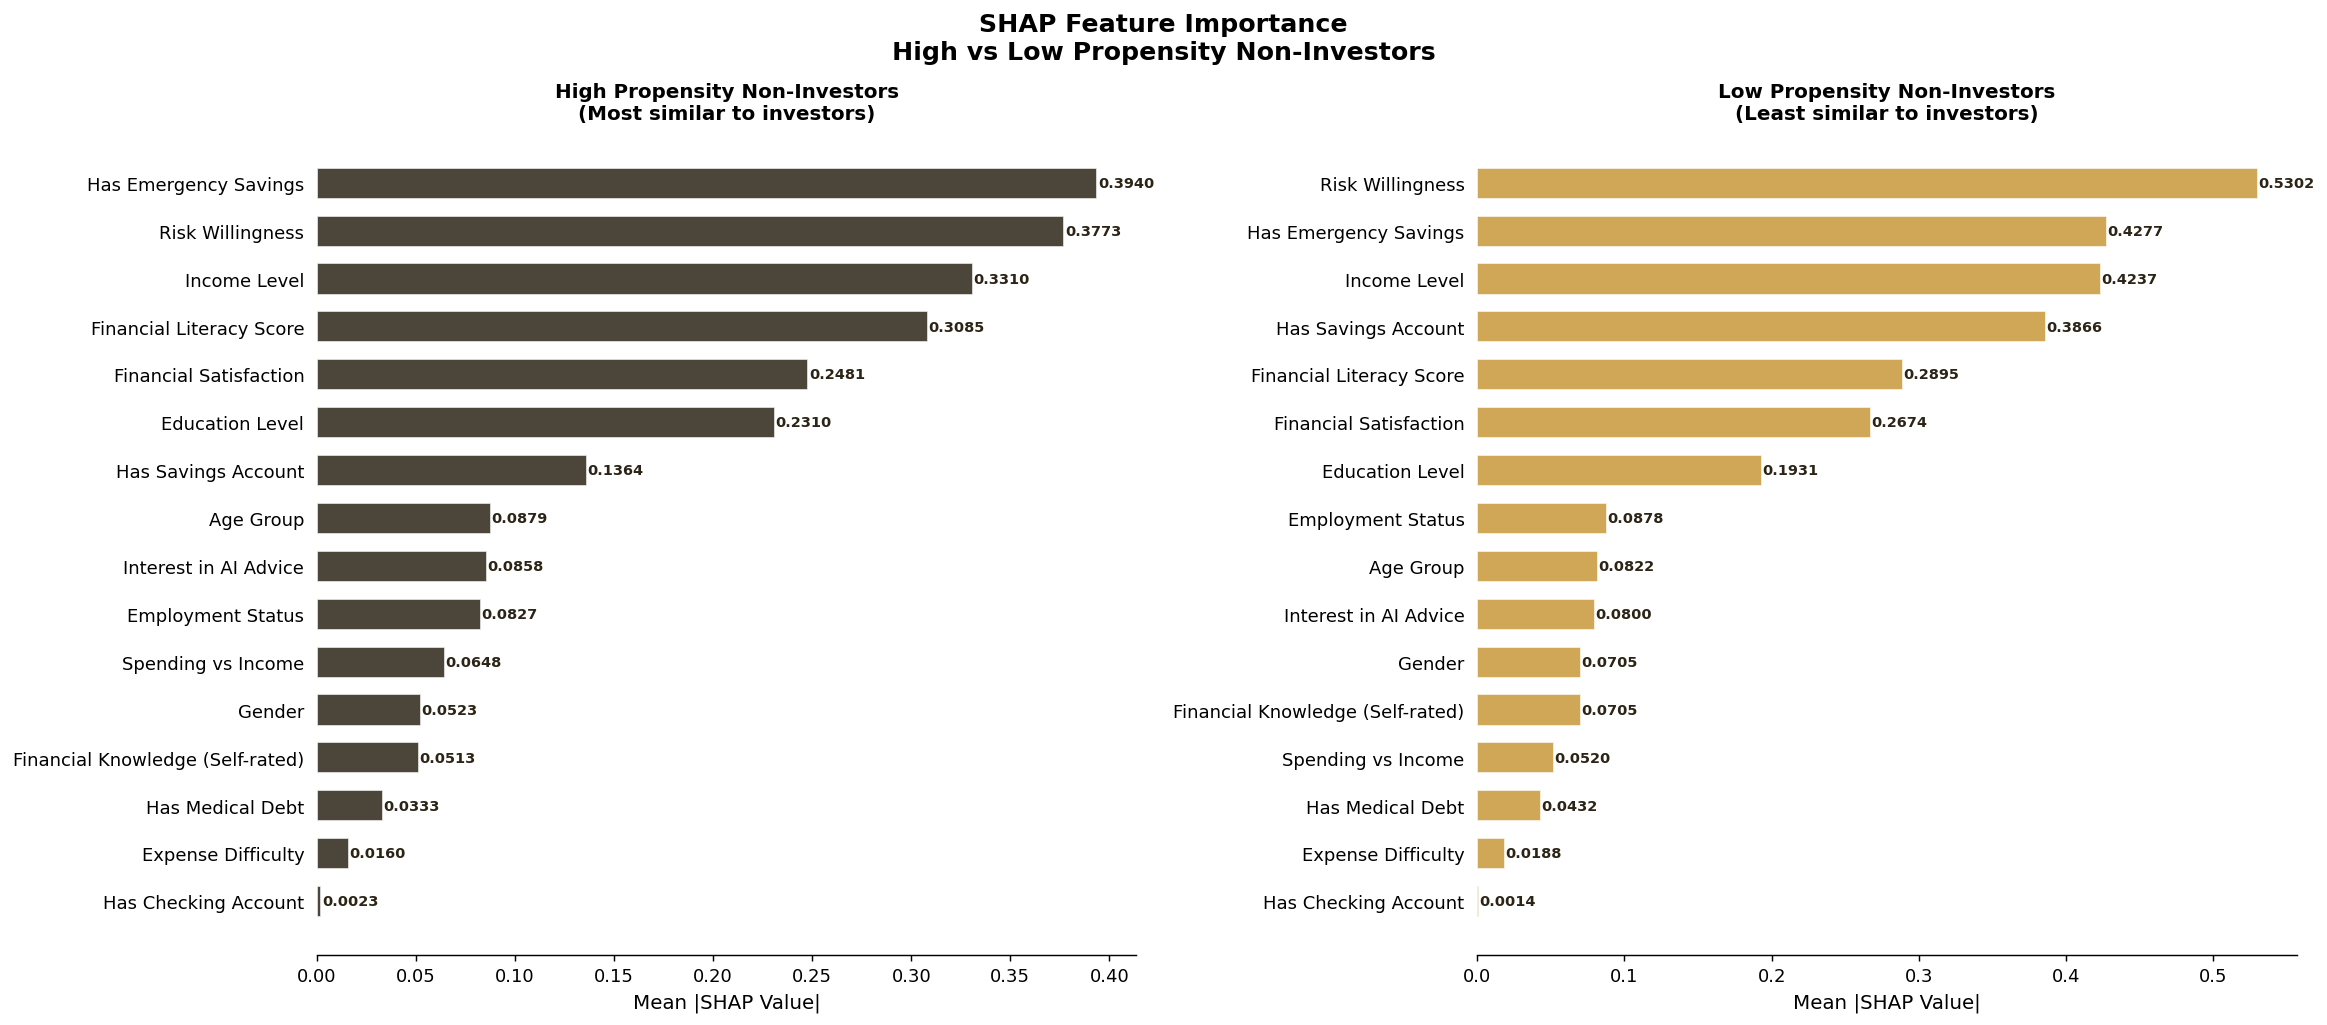

In [ ]:
high_mask = (X_non_inv['Propensity_Group'].values == 'High Propensity')
low_mask  = (X_non_inv['Propensity_Group'].values == 'Low Propensity')

high_shap = np.abs(sv_ni.values[high_mask]).mean(axis=0)
low_shap  = np.abs(sv_ni.values[low_mask]).mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('SHAP Feature Importance\n'
             'High vs Low Propensity Non-Investors',
             fontsize=14, fontweight='bold')

for ax, vals, title, col in zip(
        axes,
        [high_shap, low_shap],
        ['High Propensity Non-Investors\n(Most similar to investors)',
         'Low Propensity Non-Investors\n(Least similar to investors)'],
        [DARK, GOLD]):
    sorted_idx  = np.argsort(vals)
    sorted_feat = [FEATURE_NAMES[i] for i in sorted_idx]
    sorted_vals = vals[sorted_idx]
    ax.barh(sorted_feat, sorted_vals, color=col,
            edgecolor=WHITE, height=0.65, alpha=0.85)
    for i, v in enumerate(sorted_vals):
        ax.text(v+0.0002, i, f'{v:.4f}', va='center',
                fontsize=8, fontweight='bold', color=DARK)
    ax.set_xlabel('Mean |SHAP Value|')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.spines['left'].set_visible(False)
    ax.tick_params(left=False)

plt.tight_layout()
plt.show()

**Highest Propensity Non-Investor Waterfall**

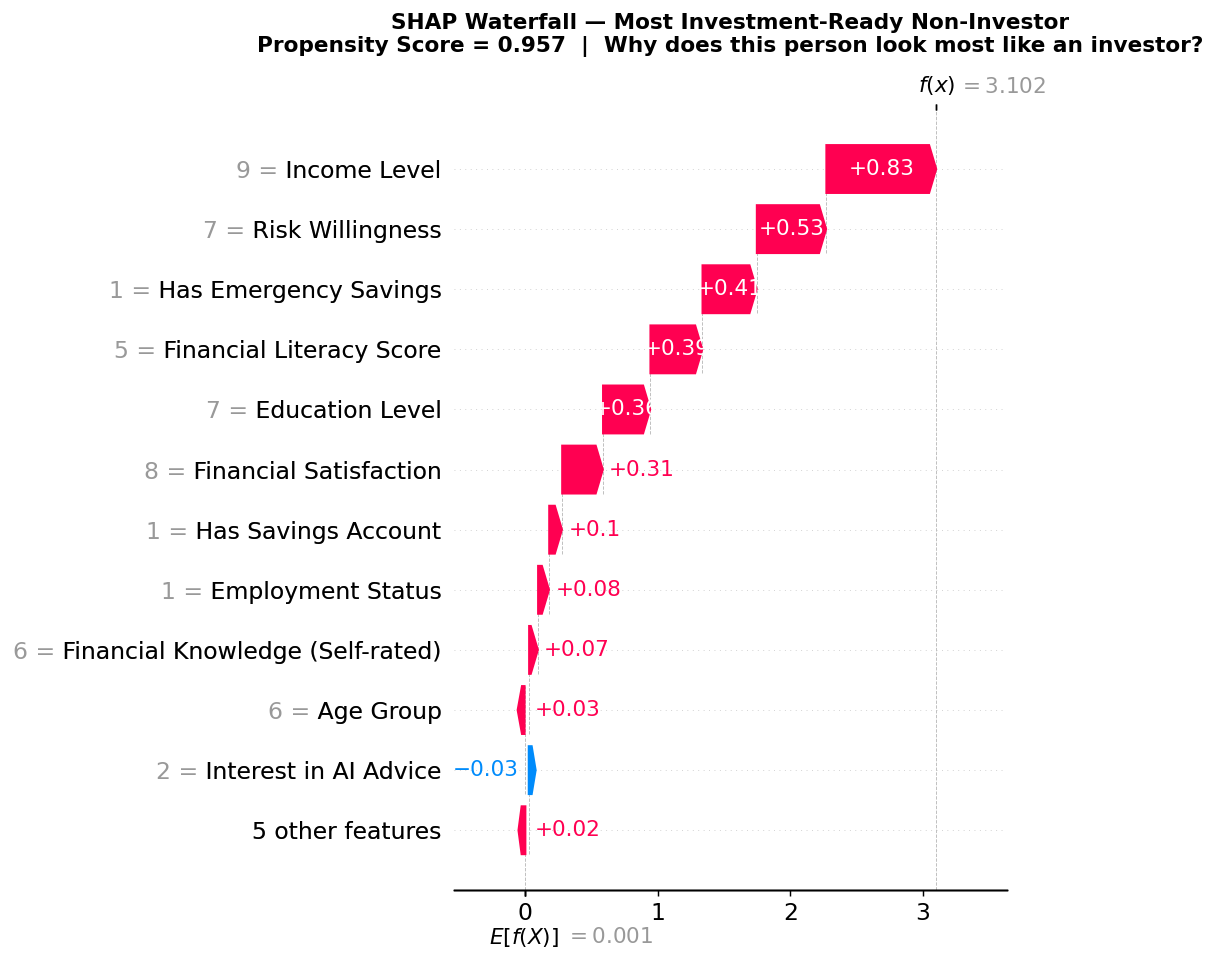

In [ ]:
highest_idx = int(np.argmax(X_non_inv['Propensity_Score'].values))

fig, ax = plt.subplots(figsize=(12, 7))
shap.waterfall_plot(sv_ni[highest_idx],
                    show=False, max_display=12)
plt.title('SHAP Waterfall — Most Investment-Ready Non-Investor\n'
          f'Propensity Score = '
          f'{X_non_inv["Propensity_Score"].max():.3f}  |  '
          'Why does this person look most like an investor?',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()